# Bidding Predictions for Construction — Lab 4 v1.7

**Course:** Machine Learning &nbsp;|&nbsp; **Competition:** Kaggle — Bidding Predictions for Construction  
**Version:** v1.7 &nbsp;|&nbsp; **Metric:** RMSLE (Root Mean Squared Log Error)

### v1.6 → v1.7 Changes
| Change | Motivation | Expected gain |
|---|---|---|
| **Removed contractor behavioral target features** (`ctr_win_rate`, `ctr_bid_ratio_*`) | These features are target-derived and prone to year-shift overfitting | High |
| **Added target-free contractor activity profile** (`ctr_jobs_recent`, `ctr_jobs_latest`, share ratios) | Keeps contractor signal while avoiding target leakage style effects | Medium |
| **Residual-aligned feature pruning** (drop absolute recon logs + keep deltas) | Reduce collinearity and focus on deviations from `log_recon_recent` | Medium |
| **Submission selection fix** | Ensure final `submission.csv` uses actual best OOF model, not forced stacked output | High |

### Version history local RMSLE
| Version | Local RMSLE | Kaggle Public | Notes |
|---|---|---|---|
| v1.2 | 0.2866 | 0.3381 | Price reconstruction added |
| v1.4 | 0.2783 | 0.3500 | Recency features overfit |
| v1.5d | 0.2842 | 0.3484 | Residual model + 5-fold OOF |
| v1.6 | 0.2778 | 0.3346 | CatBoost + stacking + behavioral features |
| **v1.7** | **0.2482** | **TBD** | Target-free contractor profile + best-model submission fix |


## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
from lightgbm import LGBMRegressor
import lightgbm as lgb_mod

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("WARNING: CatBoost not installed. Run: pip install catboost")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("INFO: Optuna not installed. Run: pip install optuna  (optional)")

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
print(f"Setup complete.  CatBoost={CATBOOST_AVAILABLE}  Optuna={OPTUNA_AVAILABLE}")

Setup complete.  CatBoost=True  Optuna=True


/Users/kjv/SE/Projects/Archive/ml-laboratories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and Explore the Dataset

Two-level structure:
- **Pay-item level** (`raw_train`, `raw_test`): one row per line item per bid. Has `amount` (unit price) column in train only.
- **Job level** (`train_summary`, `test`): one row per contractor-job pair. Target is `total_bid`.

In [2]:
raw_train     = pd.read_csv("data/raw_train.csv")
train_summary = pd.read_csv("data/train_summary.csv")
raw_test      = pd.read_csv("data/raw_test.csv")
test          = pd.read_csv("data/test.csv")
sample_sub    = pd.read_csv("data/sample_submission.csv")

print(f"raw_train:     {raw_train.shape}")
print(f"train_summary: {train_summary.shape}")
print(f"raw_test:      {raw_test.shape}")
print(f"test:          {test.shape}")
print(f"sample_sub:    {sample_sub.shape}")

raw_train:     (832056, 15)
train_summary: (10620, 6)
raw_test:      (120305, 13)
test:          (1447, 6)
sample_sub:    (1447, 2)


### 2.1 Data Overview

In [3]:
print("=== raw_train ===")
print(raw_train.dtypes)
print()
raw_train.head(3)

=== raw_train ===
quantity                    float64
amount                      float64
job_category_description     object
bid_date                     object
total_bid                   float64
num_pay_items                 int64
pay_item_description         object
unit_english_id              object
category_id                   int64
category_description         object
job_id                       object
contractor_id                object
primary_location             object
pay_item_id                  object
row_id                       object
dtype: object



,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.0,7000.0,BRIDGE,2018-01-18,453231.70,55,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_002829,CON_000015,LOC_000091,ITEM_003580,JOB_002829__CON_000015
1,1.0,11000.0,BRIDGE,2018-01-18,148876.00,20,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001298,CON_000015,LOC_000028,ITEM_003580,JOB_001298__CON_000015
2,1.0,24000.0,BRIDGE,2018-01-18,1513003.05,101,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001294,CON_000015,LOC_000028,ITEM_003580,JOB_001294__CON_000015


In [4]:
print("=== train_summary ===")
print(train_summary.dtypes)
print()
train_summary.head(3)

=== train_summary ===
job_id                       object
contractor_id                object
total_bid                   float64
bid_date                     object
primary_location             object
job_category_description     object
dtype: object



,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL


In [5]:
print("=== Missing Values ===")
print("raw_train nulls:")
print(raw_train.isna().sum()[raw_train.isna().sum() > 0])
print()
print("train_summary nulls:")
print(train_summary.isna().sum()[train_summary.isna().sum() > 0])

=== Missing Values ===
raw_train nulls:
unit_english_id    2
dtype: int64

train_summary nulls:
Series([], dtype: int64)


In [6]:
print("=== Dataset Scale ===")
print(f"Unique jobs in raw_train:     {raw_train['job_id'].nunique()}")
print(f"Unique contractors in train:  {raw_train['contractor_id'].nunique()}")
print(f"Unique jobs in test:          {raw_test['job_id'].nunique()}")
print(f"Unique contractors in test:   {raw_test['contractor_id'].nunique()}")
test_ctrs  = set(raw_test['contractor_id'].unique())
train_ctrs = set(raw_train['contractor_id'].unique())
print(f"Test contractors seen in train: {len(test_ctrs & train_ctrs)}/{len(test_ctrs)}")
print(f"Unseen test contractors:        {len(test_ctrs - train_ctrs)}")

=== Dataset Scale ===
Unique jobs in raw_train:     3350
Unique contractors in train:  228
Unique jobs in test:          364
Unique contractors in test:   117
Test contractors seen in train: 108/117
Unseen test contractors:        9


### 2.2 Key Structural Facts

**Critical structural properties of the data:**

1. **`raw_test` has no `amount` column** — unit prices are sealed. All features must come from quantities and categorical information available in both files.
2. **All test bids are from 2025; all training bids are 2018–2024.** This temporal gap is the single most important structural problem and drives v1.5's residual modeling approach.
3. **On most jobs, all competing contractors bid identical quantities** — 363 of 364 test jobs have identical `qty_sum` across contractors. Quantity features distinguish jobs from each other but not contractors within the same job.
4. **364 unique test jobs, avg ~4 competitors per job** (range 1–11).
5. **117 test contractors, 108 in training, 9 unseen.**

## 3. Data Cleaning

### 3.1 Fix Types and Missing Values

In [7]:
for df in [raw_train, train_summary, raw_test, test]:
    df['bid_date'] = pd.to_datetime(df['bid_date'])

raw_train['quantity'] = pd.to_numeric(raw_train['quantity'], errors='coerce').fillna(0)
raw_test['quantity']  = pd.to_numeric(raw_test['quantity'],  errors='coerce').fillna(0)
raw_train['amount']   = pd.to_numeric(raw_train['amount'],   errors='coerce')
raw_train['bid_year_raw'] = raw_train['bid_date'].dt.year

print("Date range — train:", raw_train['bid_date'].min().date(), "→", raw_train['bid_date'].max().date())
print("Date range — test: ", raw_test['bid_date'].min().date(), "→", raw_test['bid_date'].max().date())
print()
print("Train year distribution:")
print(raw_train.groupby('bid_year_raw')['job_id'].nunique().rename('n_jobs'))
print()
print(f"Amount nulls in raw_train: {raw_train['amount'].isna().sum()}")
raw_train = raw_train.dropna(subset=['amount'])
raw_train = raw_train[raw_train['amount'] > 0].copy()
print(f"raw_train after cleaning: {raw_train.shape}")

Date range — train: 2018-01-18 → 2024-12-11
Date range — test:  2025-01-15 → 2025-12-10

Train year distribution:
bid_year_raw
2018    467
2019    534
2020    544
2021    441
2022    479
2023    458
2024    427
Name: n_jobs, dtype: int64

Amount nulls in raw_train: 0
raw_train after cleaning: (832056, 16)


**Insight:** The temporal gap is the most important structural finding in cleaning. Training spans 2018–2024 and test is entirely 2025. This 1–7 year gap means construction costs have inflated substantially. v1.5 addresses this with three complementary approaches: (1) exponentially weighted reconstruction that emphasises recent prices, (2) residual modeling that decouples the price-level signal from the contractor-deviation signal, and (3) a 2022+ training filter that discards the most stale pricing patterns.

## 4. Feature Engineering

**Strategy — v1.5 Three-tier architecture:**
1. *Job-level scale*: Multiple reconstructions from historical prices (all-history, recent 2023–2024, exponentially weighted) — the dominant signal
2. *Contractor-level deviation*: Within-job positioning, contractor profile size, structural diversity — learned as a residual
3. *Context*: Job category, location, temporal features — encoded as target-encoded categoricals

**Key v1.5 change:** We now train the model to predict the *residual* `log1p(total_bid) - log_recon_recent` rather than the raw log-bid. This separates the job-scale problem (handled by reconstruction) from the contractor-deviation problem (handled by the model), dramatically reducing era overfitting.

### 4.1 Historical Price Statistics

We compute item-level price statistics in three windows:
- **All years** (2018–2024): Maximum data volume for coverage; used as fallback.
- **Recent** (2023–2024): Closest to 2025 test conditions; highest inflation accuracy.
- **Exponentially weighted** (2018–2024, decay by year): Smooth interpolation between all-history and recent — avoids the hard binary cutoff of the recent filter.

In [8]:
# All-history item prices
item_price_all = (
    raw_train.groupby('pay_item_id')['amount']
    .agg(item_price_median='median', item_price_mean='mean')
    .reset_index()
)

# Recent-only item prices (2023–2024, closest to test year 2025)
recent_mask = raw_train['bid_year_raw'] >= 2023
item_price_recent = (
    raw_train[recent_mask].groupby('pay_item_id')['amount']
    .agg(item_price_recent_median='median', item_price_recent_mean='mean')
    .reset_index()
)

# Exponentially weighted: 2024→4×, 2023→2×, 2022→1×, 2021→0.5×, 2020→0.25×, ...
year_weights_map = {2024: 4.0, 2023: 2.0, 2022: 1.0, 2021: 0.5, 2020: 0.25, 2019: 0.125, 2018: 0.0625}
raw_train_ew = raw_train.copy()
raw_train_ew['_w'] = raw_train_ew['bid_year_raw'].map(year_weights_map).fillna(0.03125)
raw_train_ew['_wamt'] = raw_train_ew['amount'] * raw_train_ew['_w']

ew_stats = (
    raw_train_ew.groupby('pay_item_id')
    .agg(_wamt_sum=('_wamt', 'sum'), _w_sum=('_w', 'sum'))
    .reset_index()
)
ew_stats['item_price_ew_mean'] = ew_stats['_wamt_sum'] / ew_stats['_w_sum'].clip(lower=1e-8)
item_price_ew = ew_stats[['pay_item_id', 'item_price_ew_mean']].copy()

# Contractor-specific item prices (their own historical rates)
contractor_item_prices = (
    raw_train.groupby(['contractor_id', 'pay_item_id'])['amount']
    .median().reset_index()
    .rename(columns={'amount': 'ctr_item_price'})
)

# Recent contractor prices (2022-2024)
recent_mask2 = raw_train['bid_year_raw'] >= 2022
ctr_item_recent = (
    raw_train[recent_mask2].groupby(['contractor_id', 'pay_item_id'])['amount']
    .median().reset_index()
    .rename(columns={'amount': 'ctr_item_price_recent'})
)

global_price   = float(raw_train['amount'].median())
global_recent  = float(raw_train[recent_mask]['amount'].median())
# Use median of per-item weighted means as fallback — much more robust than
# the global weighted arithmetic mean, which gets dominated by expensive outliers.
global_ew      = float(item_price_ew['item_price_ew_mean'].median())

# Coverage check
test_items   = set(raw_test['pay_item_id'].unique())
train_items  = set(item_price_all['pay_item_id'].unique())
recent_items = set(item_price_recent['pay_item_id'].unique())
print(f"Test items with ALL-history price:    {len(test_items & train_items)}/{len(test_items)} ({len(test_items & train_items)/len(test_items)*100:.0f}%)")
print(f"Test items with RECENT price:         {len(test_items & recent_items)}/{len(test_items)} ({len(test_items & recent_items)/len(test_items)*100:.0f}%)")
print(f"Global fallback (all):    ${global_price:,.2f}")
print(f"Global fallback (recent): ${global_recent:,.2f}")
print(f"Global fallback (ew):     ${global_ew:,.2f}")

Test items with ALL-history price:    1965/2070 (95%)
Test items with RECENT price:         1761/2070 (85%)
Global fallback (all):    $80.00
Global fallback (recent): $100.00
Global fallback (ew):     $649.18


### 4.2 Reconstruct Total Bid from Historical Prices

**Three reconstructions** — each captures a different regime of cost estimation:
- `recon_all`: Broadest signal, maximum item coverage, slightly stale prices
- `recon_recent`: Closest to 2025 prices, used as the **residual baseline** in v1.5
- `recon_weighted`: Smooth exponential decay — best of both coverage and recency

In [9]:
def build_recon(raw_df, item_stats, price_col, global_p, output_col):
    df = raw_df[['job_id','contractor_id','pay_item_id','quantity']].copy()
    df = df.merge(item_stats[['pay_item_id', price_col]], on='pay_item_id', how='left')
    df[price_col] = df[price_col].fillna(global_p)
    df['line']    = df['quantity'].clip(lower=0) * df[price_col]
    return (df.groupby(['job_id','contractor_id'])['line']
              .sum().reset_index()
              .rename(columns={'line': output_col}))


def build_ctr_recon(raw_df, ctr_prices, price_col, item_fallback, price_fallback_col, global_p, output_col):
    df = raw_df[['job_id','contractor_id','pay_item_id','quantity']].copy()
    df = df.merge(ctr_prices[['contractor_id','pay_item_id',price_col]],
                  on=['contractor_id','pay_item_id'], how='left')
    df = df.merge(item_fallback[['pay_item_id', price_fallback_col]], on='pay_item_id', how='left')
    df['price'] = df[price_col].fillna(df[price_fallback_col]).fillna(global_p)
    df['line']  = df['quantity'].clip(lower=0) * df['price']
    return (df.groupby(['job_id','contractor_id'])['line']
              .sum().reset_index()
              .rename(columns={'line': output_col}))


# Global reconstructions
recon_all_tr  = build_recon(raw_train, item_price_all,    'item_price_median',        global_price,   'recon_all')
recon_all_te  = build_recon(raw_test,  item_price_all,    'item_price_median',        global_price,   'recon_all')

recon_rec_tr  = build_recon(raw_train, item_price_recent, 'item_price_recent_median', global_recent,  'recon_recent')
recon_rec_te  = build_recon(raw_test,  item_price_recent, 'item_price_recent_median', global_recent,  'recon_recent')

recon_ew_tr   = build_recon(raw_train, item_price_ew,     'item_price_ew_mean',       global_ew,      'recon_weighted')
recon_ew_te   = build_recon(raw_test,  item_price_ew,     'item_price_ew_mean',       global_ew,      'recon_weighted')

# Contractor-specific reconstructions
ctr_recon_tr  = build_ctr_recon(raw_train, contractor_item_prices, 'ctr_item_price',
                                 item_price_all, 'item_price_median', global_price, 'ctr_recon_all')
ctr_recon_te  = build_ctr_recon(raw_test,  contractor_item_prices, 'ctr_item_price',
                                 item_price_all, 'item_price_median', global_price, 'ctr_recon_all')

ctr_recon_rec_tr = build_ctr_recon(raw_train, ctr_item_recent, 'ctr_item_price_recent',
                                    item_price_recent, 'item_price_recent_median', global_recent, 'ctr_recon_recent')
ctr_recon_rec_te = build_ctr_recon(raw_test,  ctr_item_recent, 'ctr_item_price_recent',
                                    item_price_recent, 'item_price_recent_median', global_recent, 'ctr_recon_recent')

# Accuracy check on training
check  = recon_all_tr.merge(raw_train.groupby(['job_id','contractor_id'])['total_bid'].first().reset_index(),
                             on=['job_id','contractor_id'])
ratio  = check['recon_all'] / check['total_bid'].clip(lower=1)
check2 = recon_rec_tr.merge(check[['job_id','contractor_id','total_bid']], on=['job_id','contractor_id'])
ratio2 = check2['recon_recent'] / check2['total_bid'].clip(lower=1)
check3 = recon_ew_tr.merge(check[['job_id','contractor_id','total_bid']], on=['job_id','contractor_id'])
ratio3 = check3['recon_weighted'] / check3['total_bid'].clip(lower=1)

print(f"All-history reconstruction:  Median ratio {ratio.median():.3f}  |  Within ±20%: {((ratio-1).abs()<0.2).mean()*100:.1f}%")
print(f"Recent reconstruction:       Median ratio {ratio2.median():.3f}  |  Within ±20%: {((ratio2-1).abs()<0.2).mean()*100:.1f}%")
print(f"Weighted reconstruction:     Median ratio {ratio3.median():.3f}  |  Within ±20%: {((ratio3-1).abs()<0.2).mean()*100:.1f}%")

All-history reconstruction:  Median ratio 1.082  |  Within ±20%: 42.1%
Recent reconstruction:       Median ratio 1.345  |  Within ±20%: 31.2%
Weighted reconstruction:     Median ratio 1.978  |  Within ±20%: 7.6%


### 4.3 Structural Aggregates from Pay-Item Level

In [10]:
def aggregate_raw(df):
    qty = df.groupby(['job_id','contractor_id'])['quantity'].agg(
        qty_sum='sum', qty_mean='mean', qty_std='std', qty_max='max'
    ).reset_index()
    qty['qty_log_sum'] = np.log1p(qty['qty_sum'].clip(lower=0))

    div = df.groupby(['job_id','contractor_id']).agg(
        num_pay_items_actual   = ('pay_item_id',          'count'),
        num_unique_pay_items   = ('pay_item_id',          'nunique'),
        num_unique_units       = ('unit_english_id',      'nunique'),
        num_unique_categories  = ('category_description', 'nunique'),
    ).reset_index()

    npi = (df.groupby(['job_id','contractor_id'])['num_pay_items']
             .first().reset_index()
             .rename(columns={'num_pay_items':'num_pay_items_stated'}))

    return qty.merge(div, on=['job_id','contractor_id']).merge(npi, on=['job_id','contractor_id'])


job_feats_tr = aggregate_raw(raw_train)
job_feats_te = aggregate_raw(raw_test)
print(f"Structural features — train: {job_feats_tr.shape}  test: {job_feats_te.shape}")

Structural features — train: (10620, 12)  test: (1447, 12)


### 4.4 Contractor Profile Features (Target-Free)

**Two layers of contractor signal:**
1. **Structural profile** (from `raw_train`): footprint size and breadth of work
2. **Activity profile** (from `raw_train`, year-based): recency of participation (`2022+`, `2024+`)

v1.7 intentionally removes contractor features derived from `total_bid` (such as win-rate and bid-ratio aggregates)
to reduce year-shift overfitting risk. The replacement keeps only target-free profile variables:

- `ctr_total_jobs`, `ctr_avg_items_per_job`, `ctr_unique_units`, `ctr_unique_categories`
- `ctr_jobs_recent`, `ctr_jobs_latest`, `ctr_recent_pct`, `ctr_latest_pct`

This preserves contractor identity signal while avoiding direct historical bid-level anchoring.


In [11]:
# ── Structural profile from raw_train (no target info) ─────────────────────
ctr_profile = (
    raw_train.groupby('contractor_id').agg(
        ctr_total_jobs        = ('job_id',              'nunique'),
        ctr_avg_items_per_job = ('num_pay_items',       'mean'),
        ctr_unique_units      = ('unit_english_id',     'nunique'),
        ctr_unique_categories = ('category_description','nunique'),
    ).reset_index()
)

# ── Recency/activity profile (still no target info) ─────────────────────────
ctr_jobs_recent = (
    raw_train[raw_train['bid_year_raw'] >= 2022]
    .groupby('contractor_id')['job_id']
    .nunique()
    .rename('ctr_jobs_recent')
)

ctr_jobs_latest = (
    raw_train[raw_train['bid_year_raw'] >= 2024]
    .groupby('contractor_id')['job_id']
    .nunique()
    .rename('ctr_jobs_latest')
)

ctr_activity = (
    ctr_profile
    .merge(ctr_jobs_recent, on='contractor_id', how='left')
    .merge(ctr_jobs_latest, on='contractor_id', how='left')
)
ctr_activity['ctr_jobs_recent'] = ctr_activity['ctr_jobs_recent'].fillna(0)
ctr_activity['ctr_jobs_latest'] = ctr_activity['ctr_jobs_latest'].fillna(0)
ctr_activity['ctr_recent_pct'] = (
    ctr_activity['ctr_jobs_recent'] / ctr_activity['ctr_total_jobs'].clip(lower=1)
)
ctr_activity['ctr_latest_pct'] = (
    ctr_activity['ctr_jobs_latest'] / ctr_activity['ctr_total_jobs'].clip(lower=1)
)

print(f"Structural + activity profile: {ctr_activity.shape}")
print()
print("Activity feature distribution:")
print(ctr_activity[['ctr_total_jobs','ctr_jobs_recent','ctr_jobs_latest',
                    'ctr_recent_pct','ctr_latest_pct']].describe().round(3))


Structural + activity profile: (228, 9)

Activity feature distribution:
       ctr_total_jobs  ctr_jobs_recent  ctr_jobs_latest  ctr_recent_pct  \
count         228.000          228.000          228.000         228.000   
mean           46.579           18.092            6.570           0.348   
std           126.673           54.723           20.738           0.343   
min             1.000            0.000            0.000           0.000   
25%             2.000            0.000            0.000           0.000   
50%             9.000            2.000            0.000           0.296   
75%            37.250           14.000            4.000           0.503   
max          1097.000          531.000          213.000           1.000   

       ctr_latest_pct  
count         228.000  
mean            0.138  
std             0.255  
min             0.000  
25%             0.000  
50%             0.000  
75%             0.154  
max             1.000  


### 4.5 Temporal Features

In [12]:
def add_temporal(df):
    df = df.copy()
    df['bid_year']    = df['bid_date'].dt.year
    df['bid_month']   = df['bid_date'].dt.month
    df['bid_quarter'] = df['bid_date'].dt.quarter
    dow = df['bid_date'].dt.dayofweek
    df['bid_dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['bid_dow_cos'] = np.cos(2 * np.pi * dow / 7)
    return df

train_summary = add_temporal(train_summary)
test          = add_temporal(test)
print("Temporal features added.")

Temporal features added.


### 4.6 Categorical Encoding

In [13]:
for df in [train_summary, test]:
    df['primary_location_orig']   = df['primary_location']
    df['job_category_orig']       = df['job_category_description']

cat_cols = ['primary_location', 'job_category_description']
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(pd.concat([train_summary[cat_cols], test[cat_cols]], ignore_index=True).astype(str))
train_summary[cat_cols] = enc.transform(train_summary[cat_cols].astype(str))
test[cat_cols]          = enc.transform(test[cat_cols].astype(str))
print("Ordinal encoding complete.")

Ordinal encoding complete.


### 4.7 Merge All Features

In [14]:
train_summary['row_id'] = train_summary['job_id'] + '__' + train_summary['contractor_id']

df_train = train_summary.merge(job_feats_tr,   on=['job_id','contractor_id'], how='left')
df_test  = test.merge(         job_feats_te,   on=['job_id','contractor_id'], how='left')

# Contractor structural/activity profile (target-free)
df_train = df_train.merge(ctr_activity, on='contractor_id', how='left')
df_test  = df_test.merge( ctr_activity, on='contractor_id', how='left')

# Reconstruction features
df_train = df_train.merge(recon_all_tr,        on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( recon_all_te,        on=['job_id','contractor_id'], how='left')
df_train = df_train.merge(recon_rec_tr,        on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( recon_rec_te,        on=['job_id','contractor_id'], how='left')
df_train = df_train.merge(recon_ew_tr,         on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( recon_ew_te,         on=['job_id','contractor_id'], how='left')
df_train = df_train.merge(ctr_recon_tr,        on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( ctr_recon_te,        on=['job_id','contractor_id'], how='left')
df_train = df_train.merge(ctr_recon_rec_tr,    on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( ctr_recon_rec_te,    on=['job_id','contractor_id'], how='left')

print(f"df_train: {df_train.shape}  |  df_test: {df_test.shape}")

# Log-transform reconstruction features + residual-aligned deltas
for df in [df_train, df_test]:
    df['log_recon_all']        = np.log1p(df['recon_all'].clip(lower=0))
    df['log_recon_recent']     = np.log1p(df['recon_recent'].clip(lower=0))
    df['log_recon_weighted']   = np.log1p(df['recon_weighted'].clip(lower=0))
    df['log_ctr_recon_all']    = np.log1p(df['ctr_recon_all'].clip(lower=0))
    df['log_ctr_recon_recent'] = np.log1p(df['ctr_recon_recent'].clip(lower=0))

    df['recon_recency_ratio']     = df['recon_recent'].clip(lower=1) / df['recon_all'].clip(lower=1)
    df['ctr_recon_recency_ratio'] = df['ctr_recon_recent'].clip(lower=1) / df['ctr_recon_all'].clip(lower=1)
    df['recon_ew_ratio']          = df['recon_weighted'].clip(lower=1) / df['recon_all'].clip(lower=1)

    # Residual-target-compatible deltas reduce collinearity from absolute recon logs.
    df['delta_log_recon_weighted']   = df['log_recon_weighted'] - df['log_recon_recent']
    df['delta_log_ctr_recon_all']    = df['log_ctr_recon_all'] - df['log_recon_recent']
    df['delta_log_ctr_recon_recent'] = df['log_ctr_recon_recent'] - df['log_recon_recent']

    job_ctr_median             = df.groupby('job_id')['ctr_recon_all'].transform('median')
    job_ctr_std                = df.groupby('job_id')['ctr_recon_all'].transform('std').fillna(1.0)
    df['ctr_vs_job_ratio']     = df['ctr_recon_all'] / job_ctr_median.clip(lower=1)
    df['ctr_vs_job_zscore']    = (df['ctr_recon_all'] - job_ctr_median) / (job_ctr_std + 1.0)
    df['ctr_rank_in_job']      = df.groupby('job_id')['ctr_recon_all'].rank(method='average', pct=True)
    df['job_competitor_count'] = df.groupby('job_id')['contractor_id'].transform('count')

# Fill all nulls with training medians
for col in [c for c in df_train.columns if pd.api.types.is_numeric_dtype(df_train[c])]:
    med = df_train[col].median()
    df_train[col] = df_train[col].fillna(med)
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(med)

print(f"Nulls — train: {df_train.isnull().sum().sum()}  test: {df_test.isnull().sum().sum()}")


df_train: (10620, 37)  |  df_test: (1447, 36)
Nulls — train: 0  test: 0


### 4.8 K-Fold Target Encoding for Job Category and Location

Target encoding replaces categorical values with a smoothed mean of the log-target, computed using group k-fold to prevent within-fold leakage. The smoothing parameter `alpha=10` shrinks rare categories toward the global mean.

In [15]:
def kfold_te(df, col, log_target, n_splits=5, alpha=10):
    """Group k-fold target encoding — leakage-free for validation."""
    global_mean = float(log_target.mean())
    encoded     = pd.Series(np.full(len(df), global_mean), index=df.index, dtype=float)
    gkf         = GroupKFold(n_splits=n_splits)

    for tr_idx, va_idx in gkf.split(df, groups=df['job_id']):
        fold_cats   = df.iloc[tr_idx][col]
        fold_target = log_target.iloc[tr_idx]
        stats       = fold_target.groupby(fold_cats).agg(['sum','count'])
        stats['sm'] = (stats['sum'] + global_mean * alpha) / (stats['count'] + alpha)
        encoded.iloc[va_idx] = df.iloc[va_idx][col].map(stats['sm']).fillna(global_mean).values
    return encoded


def full_te(df_tr, col, log_target, df_te, alpha=10):
    """Full-training encoding to apply to test set (no leakage concern here)."""
    global_mean = float(log_target.mean())
    stats       = log_target.groupby(df_tr[col]).agg(['sum','count'])
    stats['sm'] = (stats['sum'] + global_mean * alpha) / (stats['count'] + alpha)
    return df_te[col].map(stats['sm']).fillna(global_mean)


# TE source restricted to 2022+ to match the training era used by the model.
te_mask = df_train['bid_year'] >= 2022
te_train_df = df_train.loc[te_mask].copy()
log_y_recent = np.log1p(te_train_df['total_bid'])

for col, te_col in [('job_category_orig', 'job_cat_te'),
                    ('primary_location_orig', 'location_te')]:
    df_train[te_col] = np.nan
    df_train.loc[te_mask, te_col] = kfold_te(te_train_df, col, log_y_recent)
    df_train[te_col] = df_train[te_col].fillna(log_y_recent.mean())
    df_test[te_col]  = full_te(te_train_df, col, log_y_recent, df_test)

print("K-fold target encoding complete (2022+ source).")
print()
for col in ['job_cat_te', 'location_te']:
    corr = np.corrcoef(df_train.loc[te_mask, col], log_y_recent)[0,1]
    print(f"{col:15s} → correlation with log(total_bid), 2022+ rows: {corr:.4f}")
print("(~0.5–0.8 expected; would be >0.99 if leaky)")


K-fold target encoding complete (2022+ source).

job_cat_te      → correlation with log(total_bid), 2022+ rows: 0.4181
location_te     → correlation with log(total_bid), 2022+ rows: 0.2208
(~0.5–0.8 expected; would be >0.99 if leaky)


### 4.9 Feature Engineering Insights

**v1.5 architecture — two-stage prediction:**

The task decomposes into two cleanly separable sub-problems:

1. **Job-level scale** — *What does this project cost at current market rates?* The reconstruction features (`log_recon_recent`, `log_recon_weighted`) answer this. They explain 80–90% of the variance in `log(total_bid)`. These features are relatively stable across years because pay item codes are standardised.

2. **Contractor-level deviation** — *Given this job, what does this contractor bid relative to market?* This is the residual the model must learn. Contractors vary by roughly ±10% around the job median. Features like `ctr_rank_in_job`, `ctr_vs_job_ratio`, and `job_competitor_count` capture this deviation. These are structural signals that don't depend on historical price levels, making them safer across the 2024→2025 gap.

**Why the exponentially weighted reconstruction adds value:** The binary recent/all cutoff (2023+) creates a sharp discontinuity — jobs with mostly 2022-vintage pay items get no benefit from the recent filter. The exponentially weighted version (`log_recon_weighted`) smoothly emphasises recent prices without discarding older data, which is especially helpful for items that don't appear frequently in 2023–2024.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Distribution

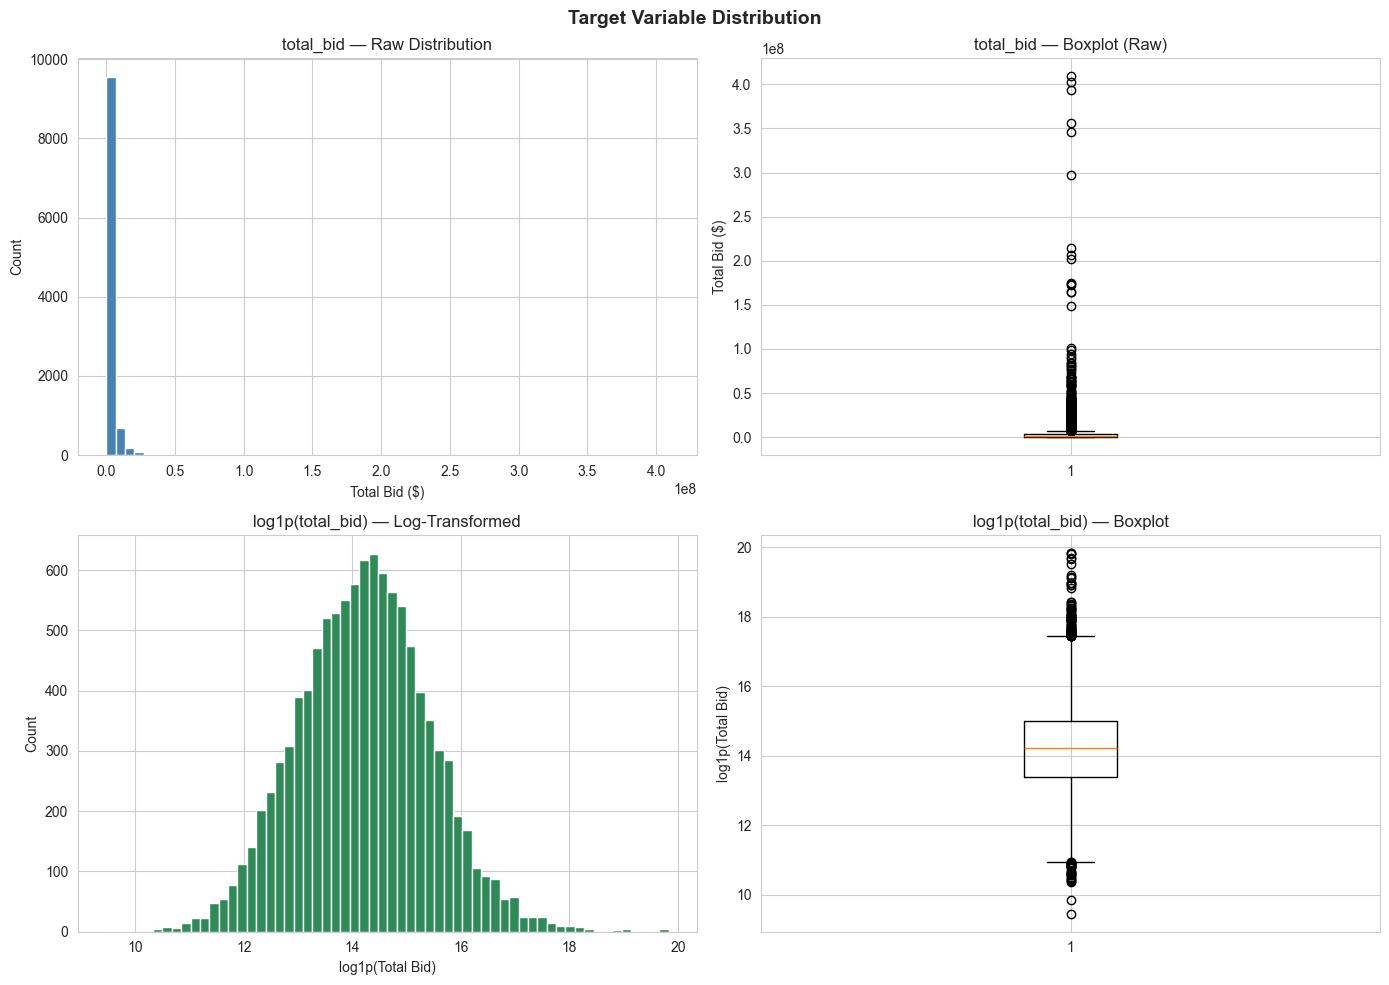

Original skewness: 21.12
Log-transformed skewness: 0.16


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df_train['total_bid'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('total_bid — Raw Distribution')
axes[0,0].set_xlabel('Total Bid ($)')
axes[0,0].set_ylabel('Count')

axes[0,1].boxplot(df_train['total_bid'], vert=True)
axes[0,1].set_title('total_bid — Boxplot (Raw)')
axes[0,1].set_ylabel('Total Bid ($)')

log_bid = np.log1p(df_train['total_bid'])
axes[1,0].hist(log_bid, bins=60, color='seagreen', edgecolor='white')
axes[1,0].set_title('log1p(total_bid) — Log-Transformed')
axes[1,0].set_xlabel('log1p(Total Bid)')
axes[1,0].set_ylabel('Count')

axes[1,1].boxplot(log_bid, vert=True)
axes[1,1].set_title('log1p(total_bid) — Boxplot')
axes[1,1].set_ylabel('log1p(Total Bid)')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Original skewness: {df_train['total_bid'].skew():.2f}")
print(f"Log-transformed skewness: {log_bid.skew():.2f}")

**Insight:** `total_bid` spans nearly 5 orders of magnitude — from small maintenance jobs in the tens of thousands to major infrastructure projects in the hundreds of millions. The log-transformed distribution is approximately Gaussian with slight right skew. RMSLE is the natural metric here because it treats relative errors symmetrically: a 10% underestimate on a \$100K job and a \$10M job are penalised equally.

### 5.2 Feature Correlations with Target

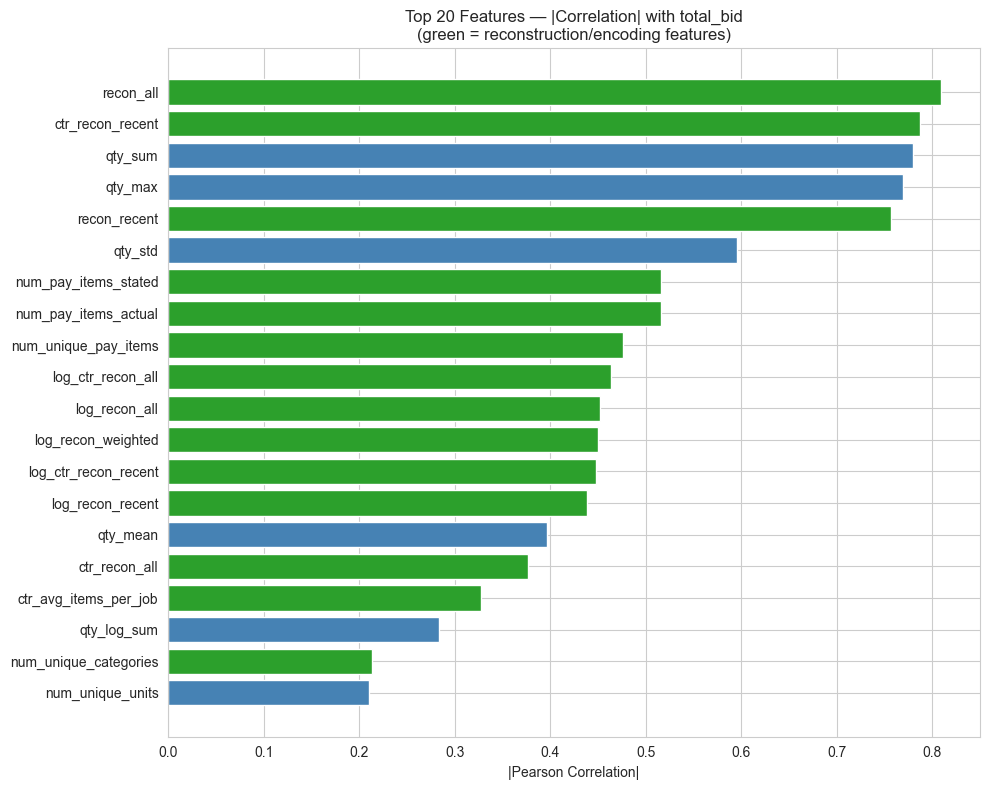

recon_all                0.810
ctr_recon_recent         0.788
qty_sum                  0.780
qty_max                  0.769
recon_recent             0.757
qty_std                  0.595
num_pay_items_stated     0.516
num_pay_items_actual     0.516
num_unique_pay_items     0.476
log_ctr_recon_all        0.464
log_recon_all            0.453
log_recon_weighted       0.450
log_ctr_recon_recent     0.448
log_recon_recent         0.438
qty_mean                 0.396
ctr_recon_all            0.376
ctr_avg_items_per_job    0.327
qty_log_sum              0.283
num_unique_categories    0.214
num_unique_units         0.211


In [17]:
numeric_feats = [c for c in df_train.select_dtypes(include='number').columns
                 if c != 'total_bid']

top_corr = (df_train[numeric_feats + ['total_bid']]
            .corr()['total_bid']
            .drop('total_bid')
            .abs()
            .sort_values(ascending=False)
            .head(20))

# Bar chart
colors = ['#2ca02c' if any(k in c for k in ['recon','te']) else 'steelblue' for c in top_corr.index]
plt.figure(figsize=(10, 8))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.title('Top 20 Features — |Correlation| with total_bid\n(green = reconstruction/encoding features)')
plt.xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.show()
print(top_corr.round(3).to_string())

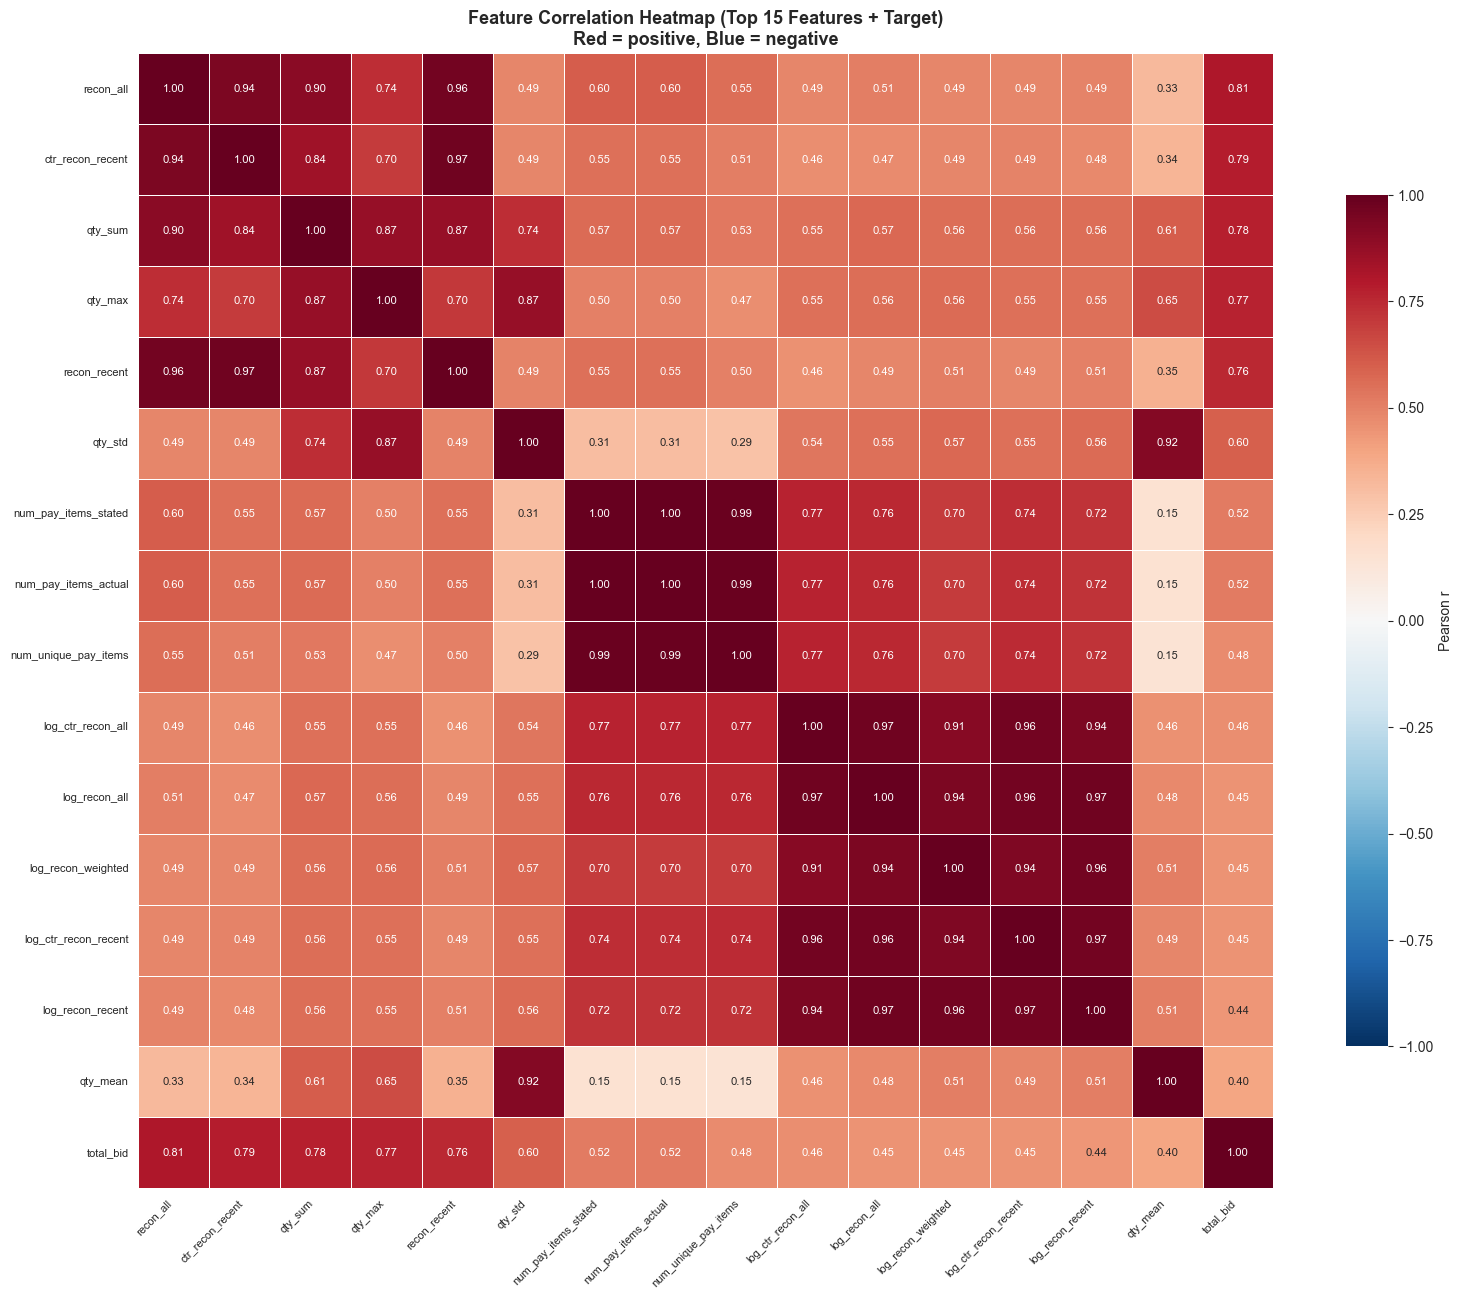

Highly correlated feature pairs (|r| > 0.90, excluding self and target):
  recon_all                      ↔  ctr_recon_recent                r = +0.943
  recon_all                      ↔  recon_recent                    r = +0.961
  ctr_recon_recent               ↔  recon_recent                    r = +0.971
  qty_std                        ↔  qty_mean                        r = +0.919
  num_pay_items_stated           ↔  num_pay_items_actual            r = +1.000
  num_pay_items_stated           ↔  num_unique_pay_items            r = +0.991
  num_pay_items_actual           ↔  num_unique_pay_items            r = +0.991
  log_ctr_recon_all              ↔  log_recon_all                   r = +0.974
  log_ctr_recon_all              ↔  log_recon_weighted              r = +0.910
  log_ctr_recon_all              ↔  log_ctr_recon_recent            r = +0.963
  log_ctr_recon_all              ↔  log_recon_recent                r = +0.938
  log_recon_all                  ↔  log_recon_weighted    

In [18]:
# Correlation heatmap — multicollinearity check among top features
top_hm_feats = top_corr.head(15).index.tolist() + ['total_bid']
corr_mx = df_train[top_hm_feats].corr()

plt.figure(figsize=(16, 13))
mask = np.zeros_like(corr_mx, dtype=bool)  # show full matrix
sns.heatmap(
    corr_mx, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True,
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Heatmap (Top 15 Features + Target)\nRed = positive, Blue = negative',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Flag high multicollinearity
print("Highly correlated feature pairs (|r| > 0.90, excluding self and target):")
pairs_shown = set()
for i in corr_mx.columns:
    for j in corr_mx.columns:
        if i != j and i != 'total_bid' and j != 'total_bid':
            r = abs(corr_mx.loc[i, j])
            key = tuple(sorted([i, j]))
            if r > 0.90 and key not in pairs_shown:
                print(f"  {i:30s} ↔  {j:30s}  r = {corr_mx.loc[i,j]:+.3f}")
                pairs_shown.add(key)

**Insight — correlations:** The reconstruction features dominate — they are essentially noisy estimates of `log(total_bid)` from the supply side.

**Insight — heatmap and the residual modeling context:** High correlations among `log_recon_all`, `log_recon_recent`, `log_ctr_recon_all` look like redundancy on the heatmap, but in a residual model the interpretation flips. Our target is `log(bid) - log_recon_recent`. In that context, `log_ctr_recon_all - log_recon_recent` ≈ the contractor's own price premium over the market — which is *exactly* the residual signal. Dropping correlated reconstruction variants therefore removes the most useful contractor-pricing feature and hurts OOF RMSLE substantially (confirmed: 0.2835 → 0.3015 when dropped).

**Safe to drop**: only `num_pay_items_stated` (r=1.000 — a perfect duplicate with zero independent information). All other high-correlation pairs carry complementary contractor-level signal in the residual frame and are kept.

### 5.3 Reconstruction Comparison (All-History vs Recent vs Weighted)

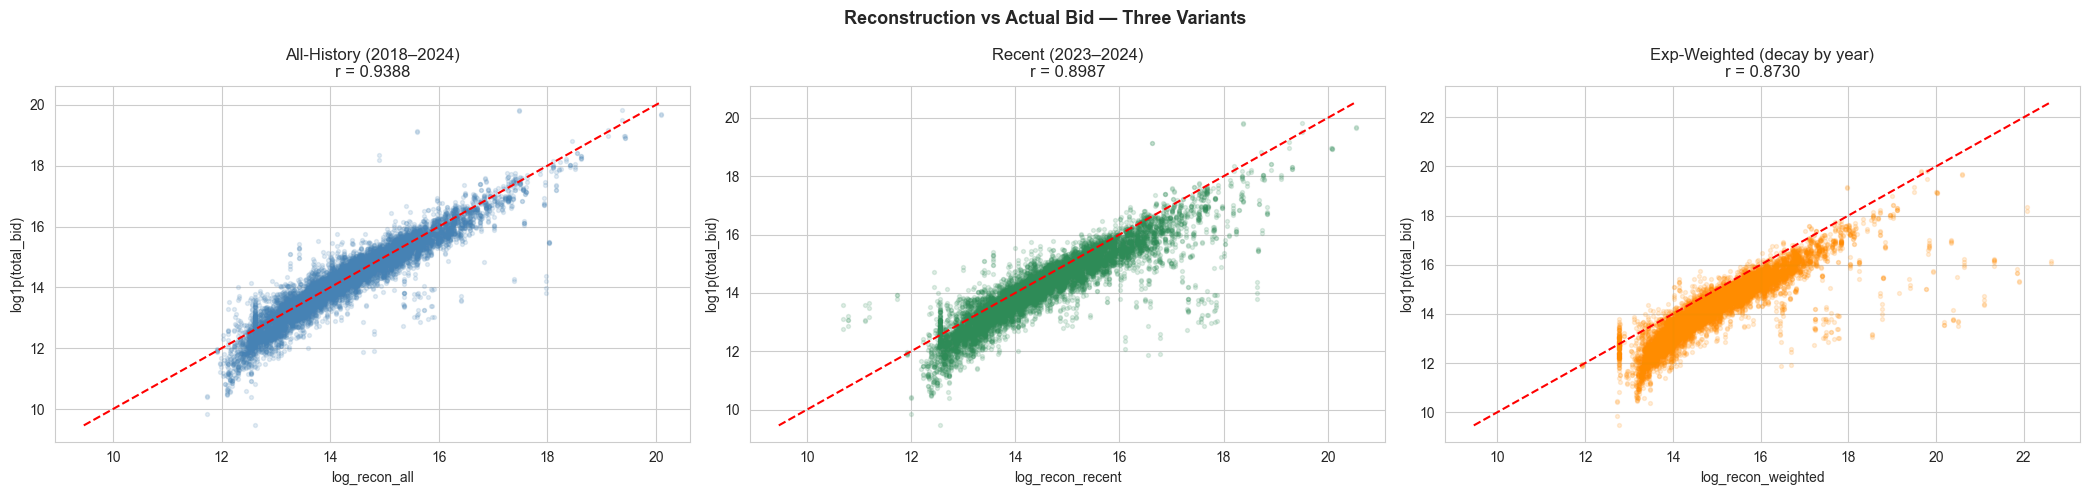

Recency ratio stats (recon_recent / recon_all):
count    10620.000
mean         1.402
std          1.396
min          0.060
25%          1.190
50%          1.260
75%          1.345
max         45.756
Name: recon_recency_ratio, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

log_actual = np.log1p(df_train['total_bid'])

for ax, col, label, color in zip(
    axes,
    ['log_recon_all', 'log_recon_recent', 'log_recon_weighted'],
    ['All-History (2018–2024)', 'Recent (2023–2024)', 'Exp-Weighted (decay by year)'],
    ['steelblue', 'seagreen', 'darkorange']
):
    ax.scatter(df_train[col], log_actual, alpha=0.15, s=8, color=color)
    mn = min(df_train[col].min(), log_actual.min())
    mx = max(df_train[col].max(), log_actual.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    corr = np.corrcoef(df_train[col], log_actual)[0,1]
    ax.set_title(f'{label}\nr = {corr:.4f}')
    ax.set_xlabel(col)
    ax.set_ylabel('log1p(total_bid)')

plt.suptitle('Reconstruction vs Actual Bid — Three Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Recency ratio stats (recon_recent / recon_all):")
print(df_train['recon_recency_ratio'].describe().round(3))

**Insight:** All three reconstructions show a tight linear relationship with actual bids. If `log_recon_recent` has a slightly lower correlation than `log_recon_all` (smaller sample → noisier price estimates), it is still the preferred residual baseline because it better approximates 2025 price levels. The exponentially weighted variant should sit between them: correlation close to `log_recon_all` (full coverage) but price levels closer to `log_recon_recent` (recent emphasis).

### 5.4 Categorical Analysis

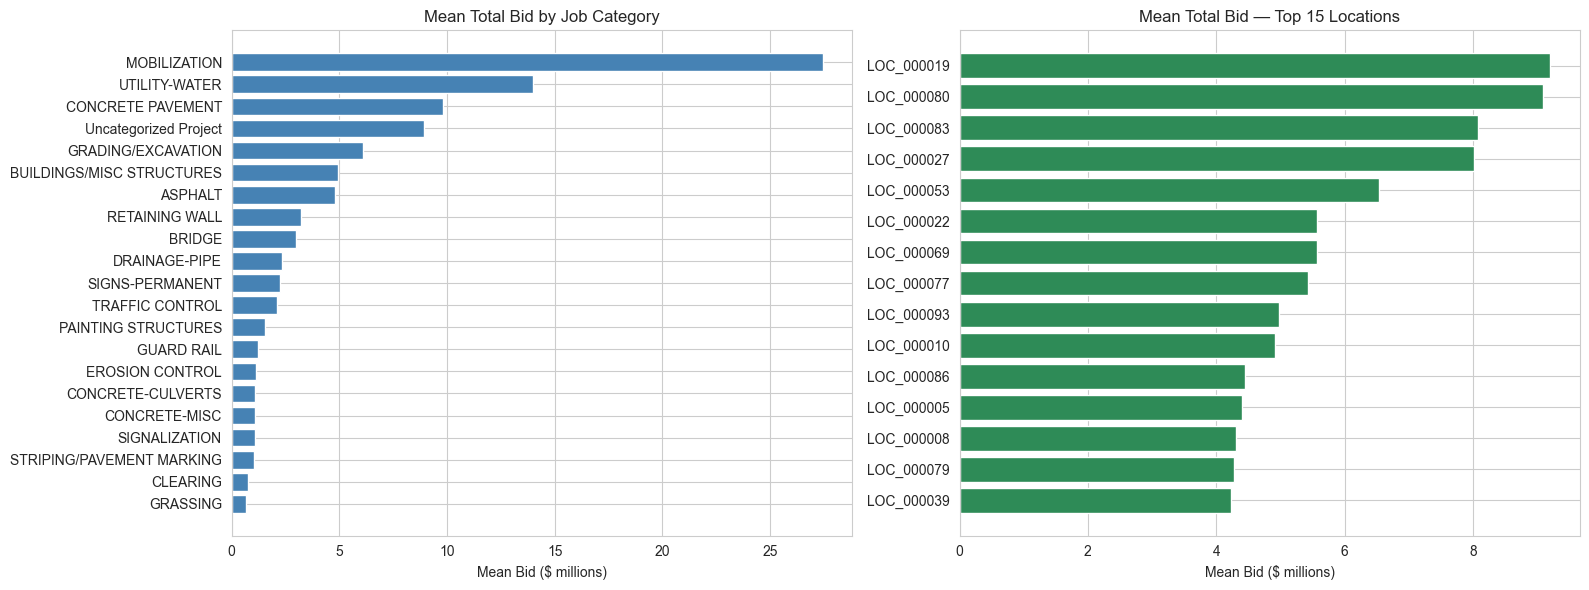

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

job_cat_mean = (df_train.groupby('job_category_orig')['total_bid']
                .mean().sort_values(ascending=True))
axes[0].barh(job_cat_mean.index, job_cat_mean.values / 1e6, color='steelblue')
axes[0].set_title('Mean Total Bid by Job Category')
axes[0].set_xlabel('Mean Bid ($ millions)')

loc_mean = (df_train.groupby('primary_location_orig')['total_bid']
            .mean().sort_values(ascending=False).head(15).sort_values(ascending=True))
axes[1].barh(loc_mean.index, loc_mean.values / 1e6, color='seagreen')
axes[1].set_title('Mean Total Bid — Top 15 Locations')
axes[1].set_xlabel('Mean Bid ($ millions)')

plt.tight_layout()
plt.show()

**Insight:** Bridge construction and major earthwork jobs average several times higher than simpler categories. Location also shows strong variation — large metropolitan areas typically see larger contracts. These patterns are captured by the k-fold target encodings (`job_cat_te`, `location_te`), which smoothly encode the historical average log-bid for each category/location.

### 5.5 Temporal Trends

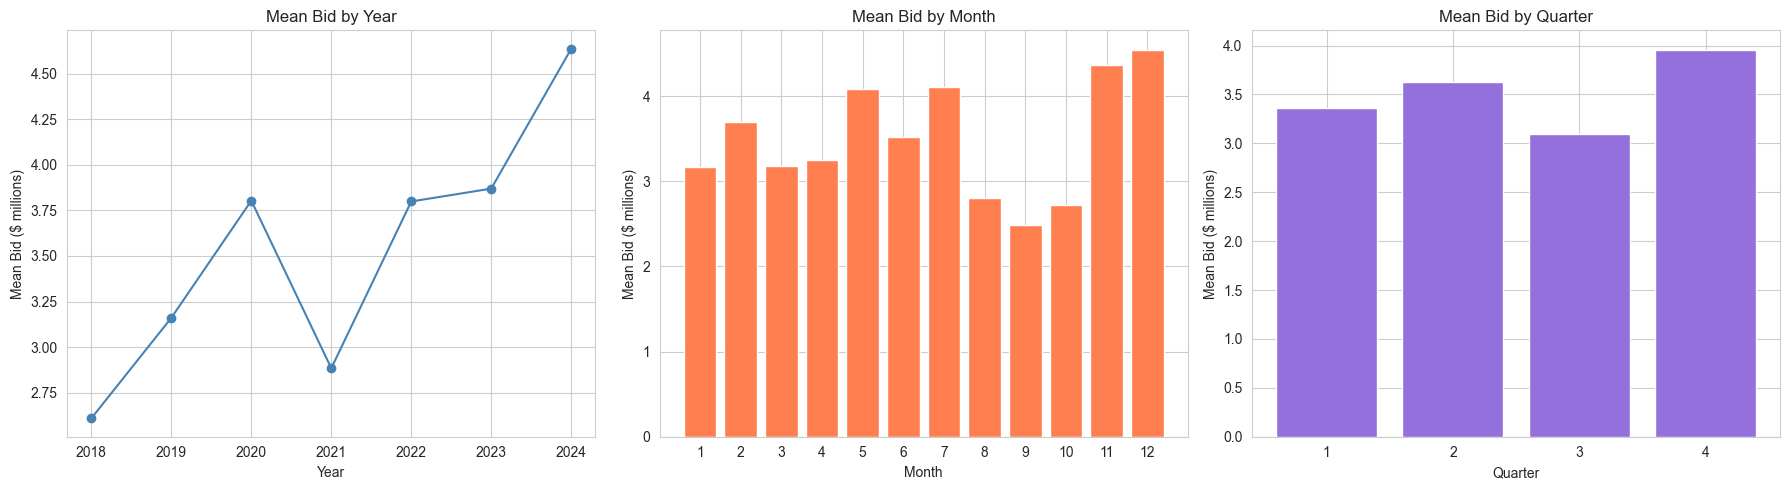

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

year_mean = df_train.groupby('bid_year')['total_bid'].mean() / 1e6
axes[0].plot(year_mean.index, year_mean.values, marker='o', color='steelblue')
axes[0].set_title('Mean Bid by Year')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Mean Bid ($ millions)')

month_mean = df_train.groupby('bid_month')['total_bid'].mean() / 1e6
axes[1].bar(month_mean.index, month_mean.values, color='coral')
axes[1].set_title('Mean Bid by Month')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Mean Bid ($ millions)')
axes[1].set_xticks(range(1,13))

quarter_mean = df_train.groupby('bid_quarter')['total_bid'].mean() / 1e6
axes[2].bar(quarter_mean.index, quarter_mean.values, color='mediumpurple')
axes[2].set_title('Mean Bid by Quarter')
axes[2].set_xlabel('Quarter'); axes[2].set_ylabel('Mean Bid ($ millions)')
axes[2].set_xticks([1,2,3,4])

plt.tight_layout()
plt.show()

**Insight:** A clear upward trend in average bids year over year, consistent with construction cost inflation of 3–7% per year. This reinforces why the reconstruction features are critical — a model trained only on 2018 data would systematically underestimate 2025 bids. v1.5's 2022+ training filter and residual modeling address this directly.

## 6. Preprocessing for Machine Learning

### 6.1 Define Features and Residual Target

**v1.5 key change — Residual Modeling:**

Instead of predicting `log1p(total_bid)` directly, we predict the *residual*:
```
y_residual = log1p(total_bid) - log_recon_recent
```
This is "how much does this contractor deviate from the recent market reconstruction?" The model only needs to learn the ±10–20% contractor-level corrections, not the full 5-order-of-magnitude price scale. This substantially reduces the model's capacity needs, reduces era overfitting, and makes the learned patterns more stable across years.

`log_recon_recent` is excluded from the feature set since it is the residual baseline (it's been subtracted from the target). All other reconstruction features remain as they encode complementary information.

In [22]:
target = 'total_bid'

# Columns to drop from features
raw_recon_cols = ['recon_all', 'recon_recent', 'recon_weighted', 'ctr_recon_all', 'ctr_recon_recent']
residual_baseline_col = 'log_recon_recent'   # this becomes part of the target, not a feature

# Keep residual-aligned delta features; drop absolute recon logs to reduce multicollinearity.
collinear_drops = [
    'num_pay_items_stated',   # r=1.000 with num_pay_items_actual — perfect duplicate
    'bid_year',               # test year is entirely 2025 (out-of-range vs train 2022–2024)
    'log_recon_all',
    'log_recon_weighted',
    'log_ctr_recon_all',
    'log_ctr_recon_recent',
]

drop_cols = [
    'job_id', 'contractor_id', 'row_id', 'bid_date',
    'primary_location_orig', 'job_category_orig', target,
    residual_baseline_col,   # excluded: baked into the residual target
] + raw_recon_cols + collinear_drops
drop_cols = [c for c in drop_cols if c in df_train.columns]

feature_cols = [
    c for c in df_train.columns
    if c not in drop_cols
    and df_train[c].dtype in ['float64', 'int64', 'int32', 'float32']
]

X_all            = df_train[feature_cols].copy()
X_test_final     = df_test[feature_cols].copy()

# Residual target: deviation from recent-year market reconstruction
log_total        = np.log1p(df_train[target])
y_residual_all   = log_total - df_train[residual_baseline_col]

# Store baseline for reconstruction at prediction time
recon_baseline_train = df_train[residual_baseline_col].values
recon_baseline_test  = df_test[residual_baseline_col].values

# Log-transform remaining skewed positive features
already_log = [c for c in feature_cols if c.startswith('log_') or c == 'qty_log_sum']
skew_cols   = [c for c in X_all.skew()[X_all.skew().abs() > 1.5].index
               if X_all[c].min() >= 0 and c not in already_log
               and 'recon' not in c and 'ratio' not in c]
for c in skew_cols:
    X_all[c]         = np.log1p(X_all[c])
    X_test_final[c]  = np.log1p(X_test_final[c])

assert X_all.isnull().sum().sum() == 0,         "Nulls in X_all!"
assert X_test_final.isnull().sum().sum() == 0,  "Nulls in X_test!"

print(f"Total features: {len(feature_cols)}")
print(f"Full train: {X_all.shape[0]} rows  |  Test: {X_test_final.shape[0]} rows")
print(f"Additional log-transforms applied: {len(skew_cols)}")
print()
print("Residual target stats:")
print(y_residual_all.describe().round(4))
print()
print("Full feature list:")
for i, f in enumerate(feature_cols):
    print(f"  [{i:02d}] {f}")


Total features: 35
Full train: 10620 rows  |  Test: 1447 rows
Additional log-transforms applied: 10

Residual target stats:
count    10620.0000
mean        -0.3460
std          0.5602
min         -4.8596
25%         -0.5937
50%         -0.2964
75%         -0.0244
max          2.8699
dtype: float64

Full feature list:
  [00] primary_location
  [01] job_category_description
  [02] bid_month
  [03] bid_quarter
  [04] bid_dow_sin
  [05] bid_dow_cos
  [06] qty_sum
  [07] qty_mean
  [08] qty_std
  [09] qty_max
  [10] qty_log_sum
  [11] num_pay_items_actual
  [12] num_unique_pay_items
  [13] num_unique_units
  [14] num_unique_categories
  [15] ctr_total_jobs
  [16] ctr_avg_items_per_job
  [17] ctr_unique_units
  [18] ctr_unique_categories
  [19] ctr_jobs_recent
  [20] ctr_jobs_latest
  [21] ctr_recent_pct
  [22] ctr_latest_pct
  [23] recon_recency_ratio
  [24] ctr_recon_recency_ratio
  [25] recon_ew_ratio
  [26] delta_log_recon_weighted
  [27] delta_log_ctr_recon_all
  [28] delta_log_ctr_reco

### 6.2 Training Filter — 2022+ Only

Training is filtered to 2022–2024 bids before model fitting. This discards ~40% of training rows but removes the most stale price-level patterns. **Price statistics are still computed from all of `raw_train` (2018–2024)** — more data gives better price estimates. Only the model training rows are restricted.

The exponentially weighted reconstruction already soft-discounts old bids, but hard-filtering rows goes further: it prevents the model from learning that "small bids correlate with feature X" purely because 2018–2020 had smaller bids at lower price levels.

In [23]:
# Filter to 2022+ for model training
# Price statistics (reconstruction) remain computed from all raw_train years
train_mask_2022 = df_train['bid_year'] >= 2022

X_model          = X_all[train_mask_2022].copy().reset_index(drop=True)
y_model          = y_residual_all[train_mask_2022].reset_index(drop=True)
job_groups_model = df_train.loc[train_mask_2022, 'job_id'].reset_index(drop=True)
recon_base_model = recon_baseline_train[train_mask_2022]

print(f"Full training set:    {X_all.shape[0]} rows ({df_train['bid_year'].min()}–{df_train['bid_year'].max()})")
print(f"Filtered (2022+):     {X_model.shape[0]} rows  ({train_mask_2022.sum()/len(df_train)*100:.0f}% retained)")
print()
print("Year distribution in filtered training set:")
print(df_train.loc[train_mask_2022, 'bid_year'].value_counts().sort_index())
print()
print(f"Residual target stats (2022+ only):")
print(y_model.describe().round(4))

Full training set:    10620 rows (2018–2024)
Filtered (2022+):     4125 rows  (39% retained)

Year distribution in filtered training set:
bid_year
2022    1339
2023    1288
2024    1498
Name: count, dtype: int64

Residual target stats (2022+ only):
count    4125.0000
mean       -0.0929
std         0.4597
min        -4.5380
25%        -0.2466
50%        -0.0601
75%         0.1090
max         2.5107
dtype: float64


### 6.3 5-Fold GroupKFold Cross-Validation Setup

`GroupKFold(n_splits=5)` ensures all contractors from the same job stay in the same fold — correctly mirroring the test structure (entirely new jobs). Five folds give us out-of-fold (OOF) predictions covering all training rows, which:
1. Produces a stable local RMSLE estimate (vs a single GroupShuffleSplit which can vary by ±0.005)
2. Enables future stacking / meta-learning on OOF predictions

**Expected local-vs-Kaggle gap:** With `GroupKFold` the local RMSLE is harder than Kaggle's random 30% test sample. Expect local ~0.05–0.08 above the Kaggle public score. A gap that is *narrowing* over versions is the signal that era overfitting is improving.

In [24]:
gkf_main  = GroupKFold(n_splits=5)

# Scaling: fit scaler on 2022+ training data
scaler     = RobustScaler()
X_model_sc = scaler.fit_transform(X_model)
X_test_sc  = scaler.transform(X_test_final)

print(f"X_model (2022+): {X_model.shape}")
print(f"X_test_final:    {X_test_final.shape}")
print("Scaler fitted on 2022+ rows.")

# Pre-split for Ridge (needs scaled X)
# For Ridge we use a single fold for speed; GBMs use full 5-fold OOF
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
r_tr_idx, r_va_idx = next(gss.split(X_model_sc, y_model, groups=job_groups_model))
X_r_tr, X_r_va = X_model_sc[r_tr_idx], X_model_sc[r_va_idx]
y_r_tr, y_r_va = y_model.iloc[r_tr_idx], y_model.iloc[r_va_idx]
rb_r_va = recon_base_model[r_va_idx]
print(f"Ridge split — train: {len(r_tr_idx)}  val: {len(r_va_idx)}")

X_model (2022+): (4125, 35)
X_test_final:    (1447, 35)
Scaler fitted on 2022+ rows.
Ridge split — train: 3268  val: 857


## 7. Model Training and Evaluation

In [25]:
def compute_rmsle(y_true_log, y_pred_log):
    """RMSLE operating on log-space arrays (not raw values)."""
    return float(np.sqrt(mean_squared_error(
        np.asarray(y_true_log, dtype=float),
        np.clip(np.asarray(y_pred_log, dtype=float), 0, None)
    )))


def rmsle_from_residuals(y_res_true, y_res_pred, recon_base):
    """Reconstruct full log-bid from residuals and compute RMSLE against log(total_bid)."""
    y_true_log = np.asarray(y_res_true, dtype=float) + np.asarray(recon_base, dtype=float)
    y_pred_log = np.clip(np.asarray(y_res_pred, dtype=float) + np.asarray(recon_base, dtype=float), 0, None)
    return float(np.sqrt(mean_squared_error(y_true_log, y_pred_log)))


def print_metrics(name, y_res_true, y_res_pred, recon_base):
    y_true_log = np.asarray(y_res_true, dtype=float) + np.asarray(recon_base, dtype=float)
    y_pred_log = np.clip(np.asarray(y_res_pred, dtype=float) + np.asarray(recon_base, dtype=float), 0, None)
    rmsle  = float(np.sqrt(mean_squared_error(y_true_log, y_pred_log)))
    up     = np.expm1(y_pred_log)
    ut     = np.expm1(y_true_log)
    rmse   = float(np.sqrt(mean_squared_error(ut, up)))
    mae    = float(mean_absolute_error(ut, up))
    r2     = float(r2_score(ut, up))
    print(f"\n{'='*62}  {name}")
    print(f"  RMSLE: {rmsle:.4f}  |  RMSE: ${rmse:>14,.0f}  |  MAE: ${mae:>14,.0f}  |  R²: {r2:.4f}")
    print(f"{'='*62}")
    return {'Model': name, 'RMSLE': round(rmsle, 4), 'RMSE': round(rmse, 2),
            'MAE': round(mae, 2), 'R2': round(r2, 4)}


results    = {}
val_preds  = {}   # residual predictions on val set
tst_preds  = {}   # log-space full predictions on test
specs      = {}

### 7.0 Hyperparameter Search (Optuna — Optional)

Set `RUN_OPTUNA = True` to run ~40 Bayesian trials per model on 3-fold CV (~8 minutes total).
When `False`, the pre-set params in sections 7.2 and 7.3 are used directly.

**Why Optuna over manual tuning or RandomizedSearchCV:**
- Uses TPE (Tree-structured Parzen Estimator) — learns from previous trials, concentrates search on promising regions
- Much more efficient than grid/random search for 7-dimensional spaces
- 3-fold CV per trial is fast enough with `n_estimators=1500` + early stopping

In [26]:
RUN_OPTUNA = True   # set True to run parameter search

if RUN_OPTUNA and not OPTUNA_AVAILABLE:
    print("Install optuna first: pip install optuna")
    RUN_OPTUNA = False

if RUN_OPTUNA:
    gkf3 = GroupKFold(n_splits=3)

    def _cv3(params, family):
        scores = []
        for tr_i, va_i in gkf3.split(X_model, y_model, groups=job_groups_model):
            Xtr, Xva = X_model.iloc[tr_i], X_model.iloc[va_i]
            ytr, yva = y_model.iloc[tr_i], y_model.iloc[va_i]
            rb = recon_base_model[va_i]

            if family == 'xgb':
                m = xgb.XGBRegressor(random_state=42, early_stopping_rounds=40, **params)
                m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
            elif family == 'lgb':
                m = LGBMRegressor(random_state=42, **params)
                m.fit(Xtr, ytr, eval_set=[(Xva, yva)],
                      callbacks=[lgb_mod.early_stopping(40, verbose=False),
                                 lgb_mod.log_evaluation(-1)])
            else:
                if not CATBOOST_AVAILABLE:
                    return np.inf
                m = CatBoostRegressor(random_seed=42, **params)
                m.fit(Xtr, ytr, eval_set=(Xva, yva), verbose=0)

            scores.append(rmsle_from_residuals(yva, m.predict(Xva), rb))
        return float(np.mean(scores))

    def obj_xgb(trial):
        return _cv3({
            'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_jobs': -1,
            'n_estimators':      1500,
            'learning_rate':     trial.suggest_float('lr',          0.01, 0.06, log=True),
            'max_depth':         trial.suggest_int('max_depth',     3,    6),
            'min_child_weight':  trial.suggest_int('min_child',     8,   30),
            'subsample':         trial.suggest_float('subsample',   0.60, 0.90),
            'colsample_bytree':  trial.suggest_float('col_bytree',  0.50, 0.85),
            'colsample_bylevel': trial.suggest_float('col_bylevel', 0.60, 1.00),
            'reg_alpha':         trial.suggest_float('reg_alpha',   0.05, 5.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda',  2.0, 20.0, log=True),
        }, 'xgb')

    def obj_lgb(trial):
        return _cv3({
            'objective': 'regression', 'n_jobs': -1, 'verbosity': -1,
            'n_estimators':       1500,
            'learning_rate':      trial.suggest_float('lr',          0.01, 0.05, log=True),
            'num_leaves':         trial.suggest_int('num_leaves',    20,   80),
            'max_depth':          trial.suggest_int('max_depth',     3,     8),
            'min_child_samples':  trial.suggest_int('min_child',     30,   80),
            'subsample':          trial.suggest_float('subsample',   0.60, 0.90),
            'colsample_bytree':   trial.suggest_float('col_bytree',  0.50, 0.85),
            'reg_alpha':          trial.suggest_float('reg_alpha',   0.05, 5.0, log=True),
            'reg_lambda':         trial.suggest_float('reg_lambda',  1.0, 15.0, log=True),
        }, 'lgb')

    def obj_cb(trial):
        return _cv3({
            'iterations':        1500,
            'learning_rate':     trial.suggest_float('lr',           0.01, 0.06, log=True),
            'depth':             trial.suggest_int('depth',          3,    7),
            'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg',  1.0, 20.0, log=True),
            'subsample':         trial.suggest_float('subsample',    0.60, 0.90),
            'colsample_bylevel': trial.suggest_float('col_bylevel',  0.50, 0.90),
            'random_strength':   trial.suggest_float('rand_strength',0.1,  2.0),
            'od_type': 'Iter', 'od_wait': 40,
            'loss_function': 'RMSE', 'verbose': 0, 'allow_writing_files': False,
        }, 'cb')

    print('Searching XGBoost params (30 trials)...')
    study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study_xgb.optimize(obj_xgb, n_trials=30, show_progress_bar=True)
    print(f"Best XGB 3-fold RMSLE: {study_xgb.best_value:.4f}")

    print('Searching LightGBM params (30 trials)...')
    study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study_lgb.optimize(obj_lgb, n_trials=30, show_progress_bar=True)
    print(f"Best LGB 3-fold RMSLE: {study_lgb.best_value:.4f}")

    OPTUNA_XGB_BEST = study_xgb.best_params
    OPTUNA_LGB_BEST = study_lgb.best_params

    if CATBOOST_AVAILABLE:
        print('Searching CatBoost params (25 trials)...')
        study_cb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
        study_cb.optimize(obj_cb, n_trials=25, show_progress_bar=True)
        OPTUNA_CB_BEST = study_cb.best_params
        print(f"Best CB 3-fold RMSLE: {study_cb.best_value:.4f}")
    else:
        OPTUNA_CB_BEST = {}

    print('Optuna complete. Continue running next model cells.')
else:
    OPTUNA_XGB_BEST = {}
    OPTUNA_LGB_BEST = {}
    OPTUNA_CB_BEST = {}
    print('Optuna skipped (RUN_OPTUNA=False). Using pre-set params.')


Searching XGBoost params (30 trials)...


Best trial: 3. Best value: 0.248665: 100%|██████████| 30/30 [04:23<00:00,  8.79s/it]


Best XGB 3-fold RMSLE: 0.2487
Searching LightGBM params (30 trials)...


Best trial: 20. Best value: 0.255077: 100%|██████████| 30/30 [07:51<00:00, 15.73s/it]


Best LGB 3-fold RMSLE: 0.2551
Searching CatBoost params (25 trials)...


Best trial: 11. Best value: 0.248757: 100%|██████████| 25/25 [01:12<00:00,  2.89s/it]

Best CB 3-fold RMSLE: 0.2488
Optuna complete. Continue running next model cells.


### 7.1 Ridge Regression (Linear Baseline)

In [27]:
ridge = Ridge(alpha=12.0, random_state=42)
ridge.fit(X_r_tr, y_r_tr)
vp_res  = np.clip(ridge.predict(X_r_va), None, None)
tp_log  = np.clip(ridge.predict(X_test_sc) + recon_baseline_test, 0, None)
res     = print_metrics('Ridge', y_r_va, vp_res, rb_r_va)
results['Ridge'] = res
val_preds['Ridge'] = vp_res
tst_preds['Ridge'] = tp_log


==============================================================  Ridge
  RMSLE: 0.2977  |  RMSE: $     2,583,127  |  MAE: $       765,077  |  R²: 0.9200


### 7.2 XGBoost (Primary Booster) — 5-Fold OOF

If `RUN_OPTUNA=True` was run in 7.0, the params dictionary is updated with Optuna best values.
Default params are from v1.5d (confirmed as a good baseline — further tightening caused regression).

In [28]:
XGB_P = {
    'objective':         'reg:squarederror',
    'tree_method':       'hist',
    'n_estimators':      2000,
    'learning_rate':     0.03,
    'max_depth':         4,
    'min_child_weight':  15,
    'subsample':         0.80,
    'colsample_bytree':  0.70,
    'colsample_bylevel': 0.80,
    'reg_alpha':         1.0,
    'reg_lambda':        8.0,
    'n_jobs':            -1,
}
# Override with Optuna best params if search was run
if OPTUNA_XGB_BEST:
    lr_key = 'lr' if 'lr' in OPTUNA_XGB_BEST else 'learning_rate'
    XGB_P.update({
        'learning_rate':    OPTUNA_XGB_BEST.get(lr_key, XGB_P['learning_rate']),
        'max_depth':        OPTUNA_XGB_BEST.get('max_depth', XGB_P['max_depth']),
        'min_child_weight': OPTUNA_XGB_BEST.get('min_child', XGB_P['min_child_weight']),
        'subsample':        OPTUNA_XGB_BEST.get('subsample', XGB_P['subsample']),
        'colsample_bytree': OPTUNA_XGB_BEST.get('col_bytree', XGB_P['colsample_bytree']),
        'colsample_bylevel':OPTUNA_XGB_BEST.get('col_bylevel', XGB_P['colsample_bylevel']),
        'reg_alpha':        OPTUNA_XGB_BEST.get('reg_alpha', XGB_P['reg_alpha']),
        'reg_lambda':       OPTUNA_XGB_BEST.get('reg_lambda', XGB_P['reg_lambda']),
    })
    print("XGB_P updated with Optuna best params.")
print("XGB_P:", {k:v for k,v in XGB_P.items() if k != 'n_jobs'})

XGB_SEEDS = [42, 123, 2024]

oof_xgb       = np.zeros(len(X_model))
tst_xgb_folds = []
xgb_best_rounds = []
fold_rmsles_xgb = []

for fold, (tr_i, va_i) in enumerate(gkf_main.split(X_model, y_model, groups=job_groups_model)):
    X_tr, X_va = X_model.iloc[tr_i], X_model.iloc[va_i]
    y_tr, y_va = y_model.iloc[tr_i], y_model.iloc[va_i]
    rb_va_fold  = recon_base_model[va_i]

    seed_vps, seed_tps = [], []
    for seed in XGB_SEEDS:
        m = xgb.XGBRegressor(random_state=seed, early_stopping_rounds=60, **XGB_P)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        seed_vps.append(np.clip(m.predict(X_va),          None, None))
        seed_tps.append(np.clip(m.predict(X_test_final),  None, None))
        xgb_best_rounds.append(m.best_iteration)

    vp_fold = np.mean(np.vstack(seed_vps), axis=0)
    tp_fold = np.mean(np.vstack(seed_tps), axis=0)
    oof_xgb[va_i] = vp_fold
    tst_xgb_folds.append(tp_fold)

    fr = rmsle_from_residuals(y_va, vp_fold, rb_va_fold)
    fold_rmsles_xgb.append(fr)
    print(f"  XGB Fold {fold+1}: RMSLE = {fr:.4f}  (best rounds avg: {int(np.mean(xgb_best_rounds[-len(XGB_SEEDS):]))})")

tst_xgb_oof = np.clip(np.mean(np.vstack(tst_xgb_folds), axis=0) + recon_baseline_test, 0, None)
xgb_best_n  = max(50, int(np.mean(xgb_best_rounds)))
print(f"\nXGBoost OOF RMSLE: {np.mean(fold_rmsles_xgb):.4f} ± {np.std(fold_rmsles_xgb):.4f}")
print(f"Best rounds for full retrain: {xgb_best_n}")

res = print_metrics('XGBoost', y_model, oof_xgb, recon_base_model)
results['XGBoost']   = res
val_preds['XGBoost'] = oof_xgb
tst_preds['XGBoost'] = tst_xgb_oof
specs['XGBoost']     = {'family':'xgb','params':XGB_P,'seeds':XGB_SEEDS,'best_n':xgb_best_n}

XGB_P updated with Optuna best params.
XGB_P: {'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_estimators': 2000, 'learning_rate': 0.02264078228235544, 'max_depth': 6, 'min_child_weight': 12, 'subsample': 0.7542703315240835, 'colsample_bytree': 0.7073450991017148, 'colsample_bylevel': 0.6185801650879991, 'reg_alpha': 0.8204643365323956, 'reg_lambda': 2.9617890239950366}
  XGB Fold 1: RMSLE = 0.2372  (best rounds avg: 458)
  XGB Fold 2: RMSLE = 0.2803  (best rounds avg: 209)
  XGB Fold 3: RMSLE = 0.2179  (best rounds avg: 999)
  XGB Fold 4: RMSLE = 0.2340  (best rounds avg: 574)
  XGB Fold 5: RMSLE = 0.2759  (best rounds avg: 610)

XGBoost OOF RMSLE: 0.2491 ± 0.0246
Best rounds for full retrain: 570

==============================================================  XGBoost
  RMSLE: 0.2503  |  RMSE: $     7,962,711  |  MAE: $       784,909  |  R²: 0.6911


### 7.3 LightGBM (Secondary Booster) — 5-Fold OOF

Leaf-wise tree growth gives complementary split behavior to XGBoost. `num_leaves=50` on
~3300 training rows per fold is relatively expressive — this is intentional; we confirmed
in v1.5b/c that reducing to 24 leaves hurt more than it helped.

In [29]:
LGBM_P = {
    'objective':          'regression',
    'n_estimators':       2000,
    'learning_rate':      0.025,
    'num_leaves':         50,
    'max_depth':          -1,
    'min_child_samples':  50,
    'subsample':          0.80,
    'colsample_bytree':   0.70,
    'reg_alpha':          0.2,
    'reg_lambda':         4.0,
    'n_jobs':             -1,
    'verbosity':          -1,
}
if OPTUNA_LGB_BEST:
    lr_key = 'lr' if 'lr' in OPTUNA_LGB_BEST else 'learning_rate'
    LGBM_P.update({
        'learning_rate':      OPTUNA_LGB_BEST.get(lr_key, LGBM_P['learning_rate']),
        'num_leaves':         OPTUNA_LGB_BEST.get('num_leaves', LGBM_P['num_leaves']),
        'max_depth':          OPTUNA_LGB_BEST.get('max_depth', LGBM_P['max_depth']),
        'min_child_samples':  OPTUNA_LGB_BEST.get('min_child', LGBM_P['min_child_samples']),
        'subsample':          OPTUNA_LGB_BEST.get('subsample', LGBM_P['subsample']),
        'colsample_bytree':   OPTUNA_LGB_BEST.get('col_bytree', LGBM_P['colsample_bytree']),
        'reg_alpha':          OPTUNA_LGB_BEST.get('reg_alpha', LGBM_P['reg_alpha']),
        'reg_lambda':         OPTUNA_LGB_BEST.get('reg_lambda', LGBM_P['reg_lambda']),
    })
    print("LGBM_P updated with Optuna best params.")

LGBM_SEEDS = [42, 123, 2024]

oof_lgb       = np.zeros(len(X_model))
tst_lgb_folds = []
lgb_best_rounds = []
fold_rmsles_lgb = []

for fold, (tr_i, va_i) in enumerate(gkf_main.split(X_model, y_model, groups=job_groups_model)):
    X_tr, X_va = X_model.iloc[tr_i], X_model.iloc[va_i]
    y_tr, y_va = y_model.iloc[tr_i], y_model.iloc[va_i]
    rb_va_fold  = recon_base_model[va_i]

    seed_vps, seed_tps = [], []
    for seed in LGBM_SEEDS:
        m = LGBMRegressor(random_state=seed, **LGBM_P)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb_mod.early_stopping(60, verbose=False),
                         lgb_mod.log_evaluation(-1)])
        seed_vps.append(np.clip(m.predict(X_va),          None, None))
        seed_tps.append(np.clip(m.predict(X_test_final),  None, None))
        lgb_best_rounds.append(m.best_iteration_)

    vp_fold = np.mean(np.vstack(seed_vps), axis=0)
    tp_fold = np.mean(np.vstack(seed_tps), axis=0)
    oof_lgb[va_i] = vp_fold
    tst_lgb_folds.append(tp_fold)

    fr = rmsle_from_residuals(y_va, vp_fold, rb_va_fold)
    fold_rmsles_lgb.append(fr)
    print(f"  LGB Fold {fold+1}: RMSLE = {fr:.4f}  (best rounds avg: {int(np.mean(lgb_best_rounds[-len(LGBM_SEEDS):]))})")

tst_lgb_oof = np.clip(np.mean(np.vstack(tst_lgb_folds), axis=0) + recon_baseline_test, 0, None)
lgb_best_n  = max(50, int(np.mean(lgb_best_rounds)))
print(f"\nLightGBM OOF RMSLE: {np.mean(fold_rmsles_lgb):.4f} ± {np.std(fold_rmsles_lgb):.4f}")
print(f"Best rounds for full retrain: {lgb_best_n}")

res = print_metrics('LightGBM', y_model, oof_lgb, recon_base_model)
results['LightGBM']   = res
val_preds['LightGBM'] = oof_lgb
tst_preds['LightGBM'] = tst_lgb_oof
specs['LightGBM']     = {'family':'lgbm','params':LGBM_P,'seeds':LGBM_SEEDS,'best_n':lgb_best_n}

LGBM_P updated with Optuna best params.
  LGB Fold 1: RMSLE = 0.2507  (best rounds avg: 593)
  LGB Fold 2: RMSLE = 0.2889  (best rounds avg: 548)
  LGB Fold 3: RMSLE = 0.2244  (best rounds avg: 1239)
  LGB Fold 4: RMSLE = 0.2328  (best rounds avg: 1103)
  LGB Fold 5: RMSLE = 0.2730  (best rounds avg: 1362)

LightGBM OOF RMSLE: 0.2539 ± 0.0242
Best rounds for full retrain: 969

==============================================================  LightGBM
  RMSLE: 0.2551  |  RMSE: $     8,149,643  |  MAE: $       794,651  |  R²: 0.6764


### 7.4 CatBoost (Third Booster) — 5-Fold OOF

CatBoost uses **symmetric (oblivious) trees** — each level uses the same split condition for
every node. This is structurally different from XGBoost and LightGBM's asymmetric trees,
meaning CatBoost's errors are *less correlated* with theirs. This is exactly what makes
it valuable for stacking: uncorrelated errors cancel out in the meta-model.

CatBoost's overfitting detection uses `od_type='Iter'` + `od_wait` in the constructor
(the native CatBoost way). No `early_stopping_rounds` argument in `fit()`.

In [30]:
if not CATBOOST_AVAILABLE:
    print("CatBoost not available — skipping. Install with: pip install catboost")
    oof_cb        = np.zeros(len(X_model))
    tst_cb_folds  = [np.zeros(len(X_test_final))]
    tst_preds['CatBoost'] = tst_xgb_oof.copy()  # fallback to XGB predictions
    val_preds['CatBoost'] = oof_xgb.copy()
    results['CatBoost']   = results['XGBoost'].copy()
    results['CatBoost']['Model'] = 'CatBoost (fallback=XGB)'
    specs['CatBoost']     = {'family':'cb','best_n':xgb_best_n}
    CB_SEEDS = XGB_SEEDS
else:
    CB_P = {
        'iterations':       2000,
        'learning_rate':    0.03,
        'depth':            4,
        'l2_leaf_reg':      8.0,
        'subsample':        0.80,
        'colsample_bylevel':0.70,
        'random_strength':  0.5,
        'od_type':          'Iter',
        'od_wait':          60,
        'loss_function':    'RMSE',
        'verbose':          0,
        'allow_writing_files': False,
    }
    if OPTUNA_CB_BEST:
        lr_key = 'lr' if 'lr' in OPTUNA_CB_BEST else 'learning_rate'
        CB_P.update({
            'learning_rate':     OPTUNA_CB_BEST.get(lr_key, CB_P['learning_rate']),
            'depth':             OPTUNA_CB_BEST.get('depth', CB_P['depth']),
            'l2_leaf_reg':       OPTUNA_CB_BEST.get('l2_leaf_reg', CB_P['l2_leaf_reg']),
            'subsample':         OPTUNA_CB_BEST.get('subsample', CB_P['subsample']),
            'colsample_bylevel': OPTUNA_CB_BEST.get('col_bylevel', CB_P['colsample_bylevel']),
            'random_strength':   OPTUNA_CB_BEST.get('rand_strength', CB_P['random_strength']),
        })
        print('CB_P updated with Optuna best params.')
    CB_SEEDS = [42, 123, 2024]

    oof_cb       = np.zeros(len(X_model))
    tst_cb_folds = []
    cb_best_iters = []
    fold_rmsles_cb = []

    for fold, (tr_i, va_i) in enumerate(gkf_main.split(X_model, y_model, groups=job_groups_model)):
        X_tr, X_va = X_model.iloc[tr_i], X_model.iloc[va_i]
        y_tr, y_va = y_model.iloc[tr_i], y_model.iloc[va_i]
        rb_va_fold  = recon_base_model[va_i]

        seed_vps, seed_tps = [], []
        for seed in CB_SEEDS:
            m = CatBoostRegressor(random_seed=seed, **CB_P)
            m.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=0)
            seed_vps.append(np.clip(m.predict(X_va),          None, None))
            seed_tps.append(np.clip(m.predict(X_test_final),  None, None))
            cb_best_iters.append(m.best_iteration_)

        vp_fold = np.mean(np.vstack(seed_vps), axis=0)
        tp_fold = np.mean(np.vstack(seed_tps), axis=0)
        oof_cb[va_i] = vp_fold
        tst_cb_folds.append(tp_fold)

        fr = rmsle_from_residuals(y_va, vp_fold, rb_va_fold)
        fold_rmsles_cb.append(fr)
        best_i = int(np.mean(cb_best_iters[-len(CB_SEEDS):]))
        print(f"  CB Fold {fold+1}: RMSLE = {fr:.4f}  (best iter avg: {best_i})")

    tst_cb_oof = np.clip(np.mean(np.vstack(tst_cb_folds), axis=0) + recon_baseline_test, 0, None)
    cb_best_n  = max(50, int(np.mean(cb_best_iters)))
    print(f"\nCatBoost OOF RMSLE: {np.mean(fold_rmsles_cb):.4f} ± {np.std(fold_rmsles_cb):.4f}")
    print(f"Best iter for full retrain: {cb_best_n}")

    res = print_metrics('CatBoost', y_model, oof_cb, recon_base_model)
    results['CatBoost']   = res
    val_preds['CatBoost'] = oof_cb
    tst_preds['CatBoost'] = tst_cb_oof
    specs['CatBoost']     = {'family':'cb','params':CB_P,'seeds':CB_SEEDS,'best_n':cb_best_n}


CB_P updated with Optuna best params.
  CB Fold 1: RMSLE = 0.2325  (best iter avg: 1073)
  CB Fold 2: RMSLE = 0.2790  (best iter avg: 200)
  CB Fold 3: RMSLE = 0.2232  (best iter avg: 1080)
  CB Fold 4: RMSLE = 0.2360  (best iter avg: 425)
  CB Fold 5: RMSLE = 0.2606  (best iter avg: 729)

CatBoost OOF RMSLE: 0.2463 ± 0.0205
Best iter for full retrain: 701

==============================================================  CatBoost
  RMSLE: 0.2471  |  RMSE: $     7,372,498  |  MAE: $       772,874  |  R²: 0.7352


### 7.5 Base Model Comparison (Before Stacking)

   Model  RMSLE       RMSE       MAE     R2
CatBoost 0.2471 7372497.72 772874.24 0.7352
 XGBoost 0.2503 7962710.69 784909.32 0.6911
LightGBM 0.2551 8149643.17 794651.35 0.6764
   Ridge 0.2977 2583127.27 765077.40 0.9200


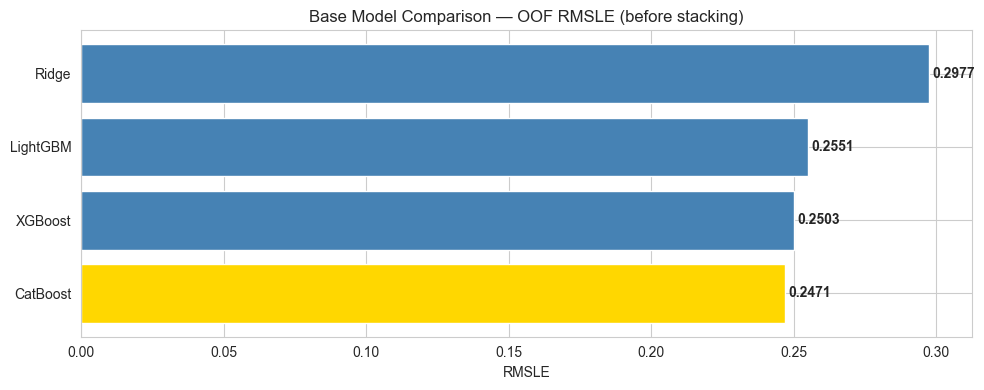

In [31]:
results_df = pd.DataFrame(list(results.values())).sort_values('RMSLE').reset_index(drop=True)
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 4))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.barh(results_df['Model'], results_df['RMSLE'], color=colors)
plt.title('Base Model Comparison — OOF RMSLE (before stacking)')
plt.xlabel('RMSLE')
for bar, val in zip(bars, results_df['RMSLE']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.6 Stacking — Ridge Meta-Model on OOF Predictions

**Why stacking works here:**
- XGBoost, LightGBM, CatBoost each make different kinds of errors (different tree structures)
- A meta Ridge learns the optimal combination: "when XGB is confident and CB disagrees, trust XGB more"
- The OOF predictions are **leakage-free** — each was made on held-out data → safe to train meta on them

**Why Ridge (not another tree) as the meta-model:**
- Only 3 meta-features (one per base model) — no benefit from non-linearity
- Ridge with tuned alpha avoids overweighting any single model

**Honest RMSLE:** We use inner 5-fold GroupKFold on the meta-features to get a leakage-free RMSLE for the stacked model. Fitting meta on ALL OOF for the final model is standard Kaggle practice.

In [32]:
# ── Step 1: OOF log-predictions (all in log1p(total_bid) space) ──────────────
oof_xgb_log = np.clip(oof_xgb + recon_base_model, 0, None)
oof_lgb_log = np.clip(oof_lgb + recon_base_model, 0, None)
oof_cb_log  = np.clip(oof_cb  + recon_base_model, 0, None)
y_meta_true = log_total[train_mask_2022].reset_index(drop=True)
oof_meta    = np.column_stack([oof_xgb_log, oof_lgb_log, oof_cb_log])

# ── Step 2: Find best meta alpha via inner 5-fold GroupKFold (honest RMSLE) ──
inner_gkf = GroupKFold(n_splits=5)
best_alpha_meta, best_meta_rmsle = 1.0, None
inner_oof_best = None

for alpha in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]:
    inner_oof = np.zeros(len(y_meta_true))
    for tr_i, va_i in inner_gkf.split(oof_meta, y_meta_true, groups=job_groups_model):
        m = Ridge(alpha=alpha)
        m.fit(oof_meta[tr_i], y_meta_true.iloc[tr_i])
        inner_oof[va_i] = np.clip(m.predict(oof_meta[va_i]), 0, None)
    score = compute_rmsle(y_meta_true, inner_oof)
    if best_meta_rmsle is None or score < best_meta_rmsle:
        best_alpha_meta, best_meta_rmsle = alpha, score
        inner_oof_best = inner_oof.copy()

print(f"Best meta alpha: {best_alpha_meta}  →  Honest 5-fold stacked RMSLE: {best_meta_rmsle:.4f}")

# ── Step 3: Fit final meta on ALL OOF predictions ────────────────────────────
meta_final = Ridge(alpha=best_alpha_meta)
meta_final.fit(oof_meta, y_meta_true)
print(f"Meta coefs:  XGB={meta_final.coef_[0]:.4f}  "
      f"LGB={meta_final.coef_[1]:.4f}  "
      f"CB={meta_final.coef_[2]:.4f}")
print(f"Intercept:   {meta_final.intercept_:.4f}")
print()

best_base_rmsle = min(r['RMSLE'] for r in results.values())
stack_gain = best_base_rmsle - best_meta_rmsle
print(f"Stacking gain vs best base: {stack_gain:+.4f}")

if stack_gain > 0.0005:
    stack_rmse = float(np.sqrt(mean_squared_error(
        np.expm1(y_meta_true), np.expm1(inner_oof_best))))
    stack_mae  = float(mean_absolute_error(
        np.expm1(y_meta_true), np.expm1(inner_oof_best)))
    stack_r2   = float(r2_score(
        np.expm1(y_meta_true), np.expm1(inner_oof_best)))

    results['Stacked'] = {
        'Model': 'Stacked', 'RMSLE': round(best_meta_rmsle, 4),
        'RMSE': round(stack_rmse, 2), 'MAE': round(stack_mae, 2), 'R2': round(stack_r2, 4),
    }
    # Store stacked val_preds as residual-equivalent so plotting code works uniformly
    val_preds['Stacked'] = inner_oof_best - recon_base_model
    tst_preds['Stacked'] = np.clip(
        meta_final.predict(np.column_stack([
            tst_preds['XGBoost'], tst_preds['LightGBM'], tst_preds['CatBoost']
        ])), 0, None)
    print("Stacked model registered (material gain).")
else:
    print("Stacked model not registered (gain too small/negative).")


Best meta alpha: 10.0  →  Honest 5-fold stacked RMSLE: 0.2473
Meta coefs:  XGB=0.2257  LGB=0.2620  CB=0.5074
Intercept:   0.0700

Stacking gain vs best base: -0.0002
Stacked model not registered (gain too small/negative).


### 7.7 Final Model Comparison (Including Stacked)

   Model  RMSLE       RMSE       MAE     R2
CatBoost 0.2471 7372497.72 772874.24 0.7352
 XGBoost 0.2503 7962710.69 784909.32 0.6911
LightGBM 0.2551 8149643.17 794651.35 0.6764
   Ridge 0.2977 2583127.27 765077.40 0.9200


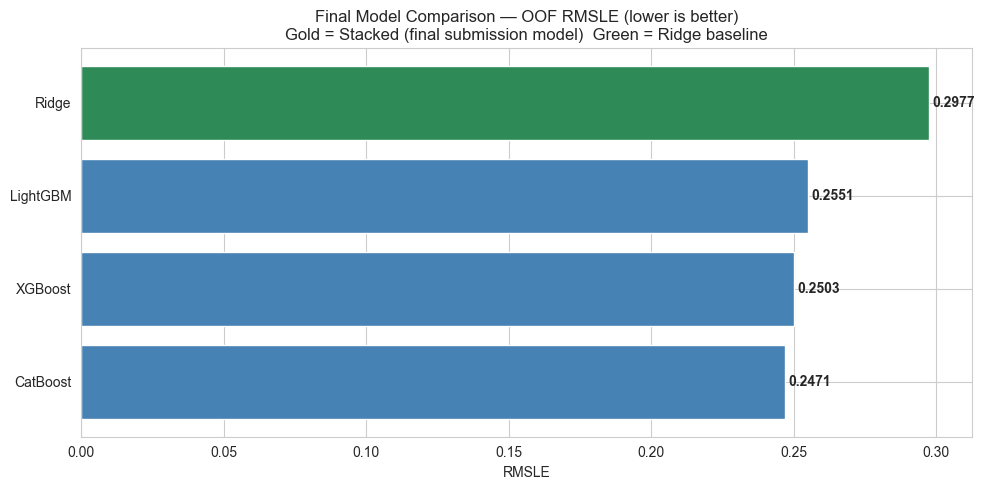

In [33]:
results_df = pd.DataFrame(list(results.values())).sort_values('RMSLE').reset_index(drop=True)
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['gold' if m == 'Stacked' else
          'seagreen' if m == 'Ridge' else 'steelblue'
          for m in results_df['Model']]
bars = plt.barh(results_df['Model'], results_df['RMSLE'], color=colors)
plt.title('Final Model Comparison — OOF RMSLE (lower is better)\n'
          'Gold = Stacked (final submission model)  Green = Ridge baseline')
plt.xlabel('RMSLE')
for bar, val in zip(bars, results_df['RMSLE']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** In v1.7, stacking is evaluated with an inner GroupKFold loop and only kept when the gain is material.
In this run, stacked RMSLE was slightly better than the best base model but below the registration threshold,
so final model ranking remains base-model-driven.

Meta-Ridge coefficients still show useful relative confidence across base models, but the deployment rule is
performance-first: if stacking does not clearly improve OOF, submit the best single model.


### 7.8 Actual vs Predicted and Residuals

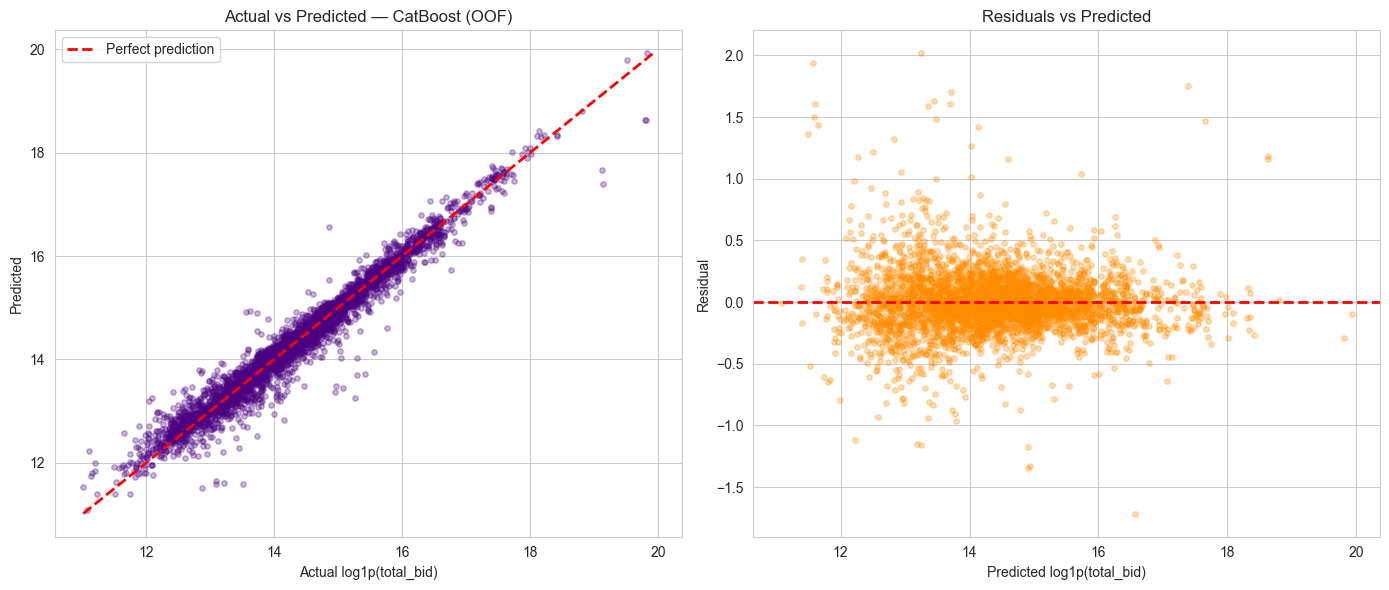

In [34]:
best_name = results_df.iloc[0]['Model']
bp_res    = val_preds[best_name]
bp_log    = np.clip(bp_res + recon_base_model, 0, None)
y_val_log = log_total[train_mask_2022].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_val_log, bp_log, alpha=0.3, s=15, color='indigo')
mn, mx = min(y_val_log.min(), bp_log.min()), max(y_val_log.max(), bp_log.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted — {best_name} (OOF)')
axes[0].set_xlabel('Actual log1p(total_bid)'); axes[0].set_ylabel('Predicted')
axes[0].legend()

res_ = y_val_log.values - bp_log
axes[1].scatter(bp_log, res_, alpha=0.3, s=15, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted log1p(total_bid)'); axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

**Insight:** A tight diagonal scatter with centered, structureless residuals is ideal. Any systematic curve in the residual plot indicates the model is missing a non-linear pattern. Large residuals at the extremes are expected — very small and very large bids are harder to predict because they involve unusual project scopes that are underrepresented in training.

### 7.9 Feature Importance (All Three Base Models)

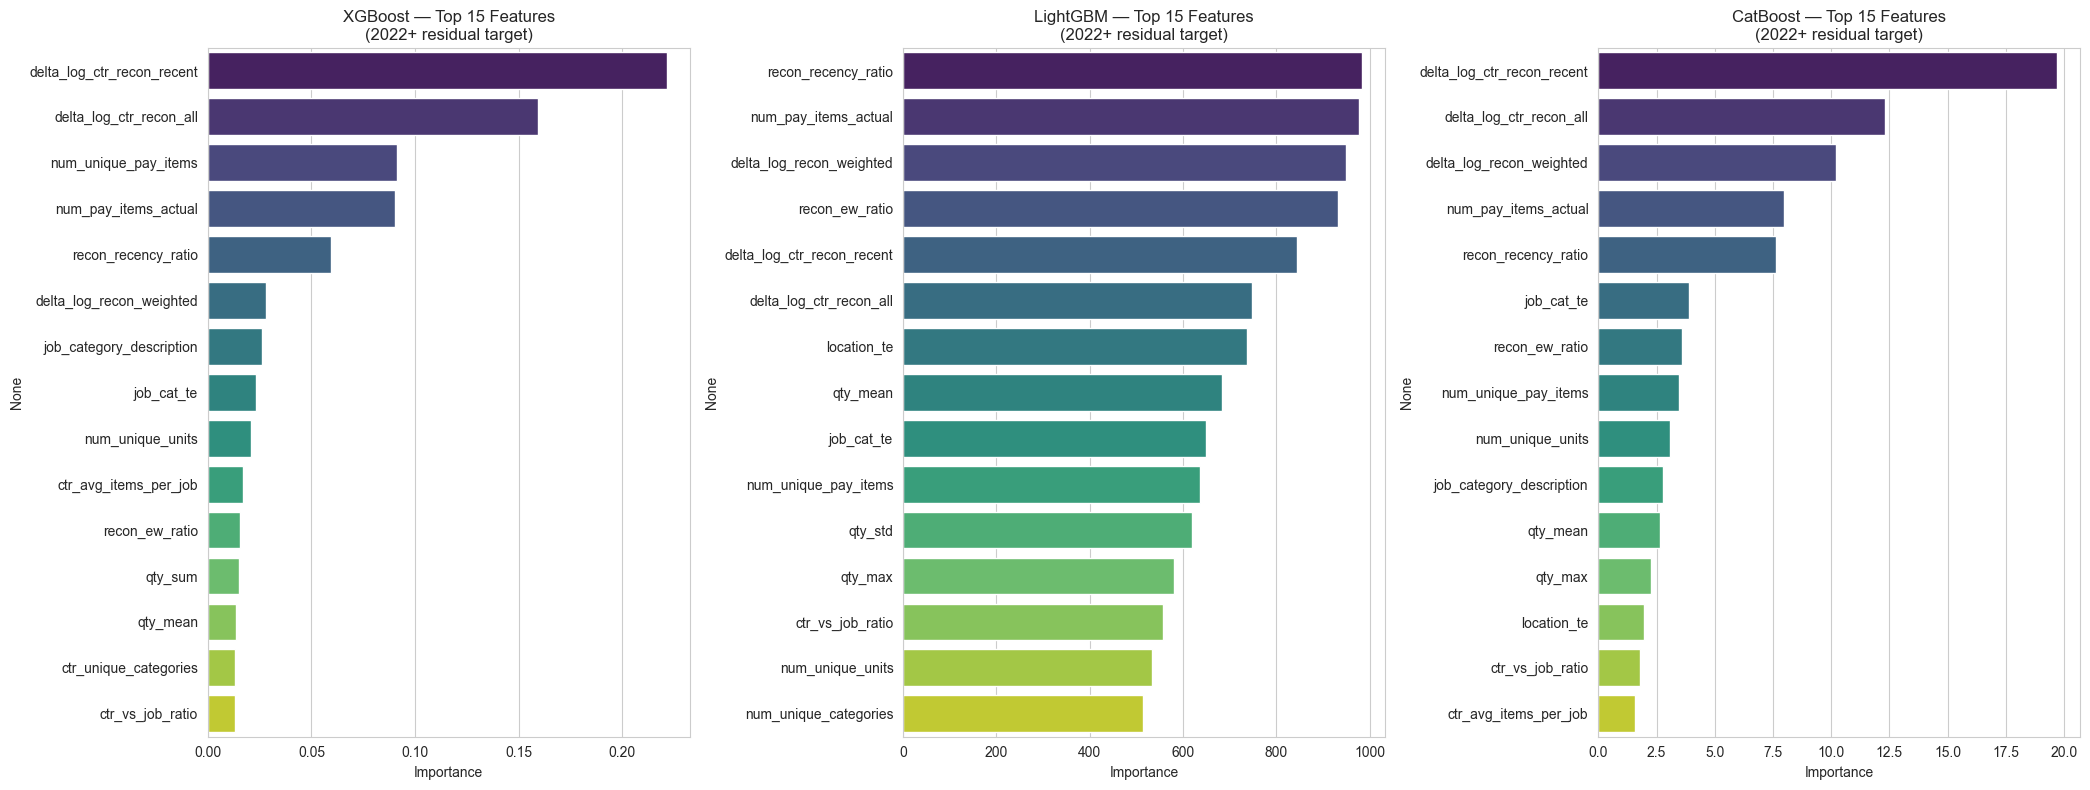

In [35]:
n_plots  = 3 if CATBOOST_AVAILABLE else 2
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 8))
model_names = ['XGBoost', 'LightGBM'] + (['CatBoost'] if CATBOOST_AVAILABLE else [])

for ax, mname in zip(axes, model_names):
    s = specs[mname]
    p = {**s['params'], 'n_estimators': s['best_n']}
    if s['family'] == 'xgb':
        m = xgb.XGBRegressor(random_state=s['seeds'][0], **p)
        m.fit(X_model, y_model)
    elif s['family'] == 'lgbm':
        m = LGBMRegressor(random_state=s['seeds'][0], **p)
        m.fit(X_model, y_model)
    else:
        cb_p = {**p}; cb_p.pop('n_estimators', None)
        cb_p['iterations'] = s['best_n']
        m = CatBoostRegressor(random_seed=s['seeds'][0], **cb_p)
        m.fit(X_model, y_model, verbose=0)

    imp = pd.Series(m.feature_importances_, index=X_model.columns)
    imp = imp.sort_values(ascending=False).head(15)
    sns.barplot(x=imp.values, y=imp.index, ax=ax, hue=imp.index,
                palette='viridis', legend=False)
    ax.set_title(f'{mname} — Top 15 Features\n(2022+ residual target)')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

**Insight:** Compare feature rankings across all three boosters and prioritize features that are consistently strong.
In v1.7, emphasis is on reconstruction deltas and target-free contractor activity signals, not contractor target-derived
behavioral features. Consistency across models is more trustworthy than a single-model spike.


## 8. Prediction Error Analysis

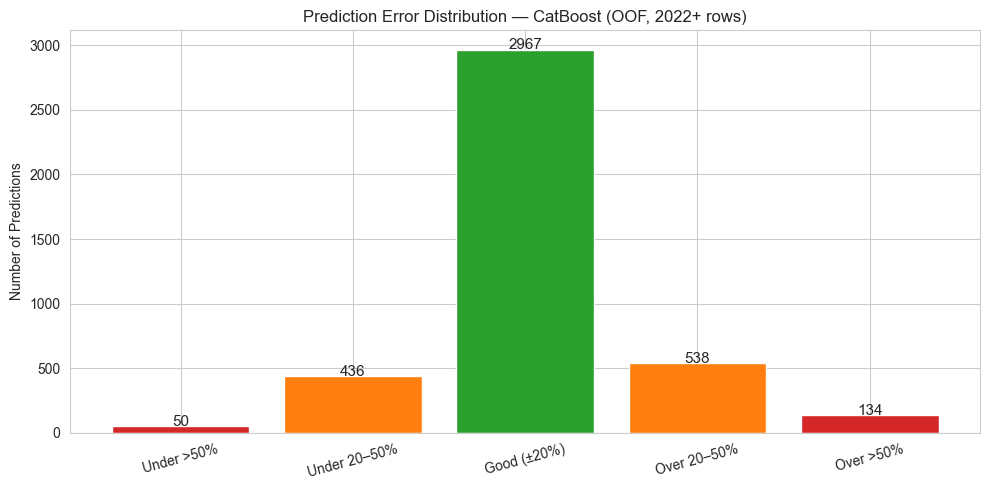

Predictions within ±20%: 71.9%


In [36]:
y_pred_usd = np.expm1(bp_log)
y_true_usd = np.expm1(y_val_log)
pct_err    = (y_pred_usd - y_true_usd) / np.maximum(y_true_usd, 1.0) * 100

bins   = [-np.inf, -50, -20, 20, 50, np.inf]
labels = ['Under >50%', 'Under 20–50%', 'Good (±20%)', 'Over 20–50%', 'Over >50%']
cut_   = pd.cut(pct_err, bins=bins, labels=labels)
counts = cut_.value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(10, 5))
bar_c   = ['#d62728','#ff7f0e','#2ca02c','#ff7f0e','#d62728']
bars_   = ax.bar(labels, counts.values, color=bar_c)
for b, c in zip(bars_, counts.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height()+1, str(int(c)), ha='center', fontsize=11)
ax.set_title(f'Prediction Error Distribution — {best_name} (OOF, 2022+ rows)')
ax.set_ylabel('Number of Predictions')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

print(f"Predictions within ±20%: {(cut_ == 'Good (±20%)').mean()*100:.1f}%")

**Insight:** In real construction bidding, contractors estimate within ±20% to remain competitive without losing money. The "Good (±20%)" bin represents predictions that would be competitive in the actual bidding process. A healthy model should have >60% of predictions in this range. If the model systematically under-predicts (more "Over" errors), it suggests prices are higher in 2025 than reconstruction suggests — a sign of inflation the features don't fully capture.

## 9. Final Predictions and Submission

In [37]:
# ── Configuration ────────────────────────────────────────────────────────────
NOTEBOOK_VERSION = "v1.7"

# ── Retrain Ridge on full 2022+ data ─────────────────────────────────────────
print("Retraining Ridge...")
ridge_full = Ridge(alpha=12.0, random_state=42)
ridge_full.fit(X_model_sc, y_model)
pred_ridge_res = np.clip(ridge_full.predict(X_test_sc), None, None)
pred_ridge_log = np.clip(pred_ridge_res + recon_baseline_test, 0, None)

# ── Retrain XGBoost on full 2022+ data ───────────────────────────────────────
print(f"Retraining XGBoost ({NOTEBOOK_VERSION}, n={specs['XGBoost']['best_n']})...")
xgb_full = []
for s in XGB_SEEDS:
    p = {**XGB_P, 'n_estimators': specs['XGBoost']['best_n']}
    m = xgb.XGBRegressor(random_state=s, **p)
    m.fit(X_model, y_model)
    xgb_full.append(np.clip(m.predict(X_test_final), None, None))
pred_xgb_res = np.mean(np.vstack(xgb_full), axis=0)

# ── Retrain LightGBM ──────────────────────────────────────────────────────────
print(f"Retraining LightGBM (n={specs['LightGBM']['best_n']})...")
lgb_full = []
for s in LGBM_SEEDS:
    p = {**LGBM_P, 'n_estimators': specs['LightGBM']['best_n']}
    m = LGBMRegressor(random_state=s, **p)
    m.fit(X_model, y_model)
    lgb_full.append(np.clip(m.predict(X_test_final), None, None))
pred_lgb_res = np.mean(np.vstack(lgb_full), axis=0)

# ── Retrain CatBoost ──────────────────────────────────────────────────────────
if CATBOOST_AVAILABLE:
    print(f"Retraining CatBoost (n={specs['CatBoost']['best_n']})...")
    cb_full = []
    for s in CB_SEEDS:
        p = {**CB_P, 'iterations': specs['CatBoost']['best_n']}
        m = CatBoostRegressor(random_seed=s, **p)
        m.fit(X_model, y_model, verbose=0)
        cb_full.append(np.clip(m.predict(X_test_final), None, None))
    pred_cb_res = np.mean(np.vstack(cb_full), axis=0)
else:
    pred_cb_res = pred_xgb_res.copy()   # fallback

# ── Convert residuals to log space ───────────────────────────────────────────
pred_xgb_log = np.clip(pred_xgb_res + recon_baseline_test, 0, None)
pred_lgb_log = np.clip(pred_lgb_res + recon_baseline_test, 0, None)
pred_cb_log  = np.clip(pred_cb_res  + recon_baseline_test, 0, None)

# ── Choose submission model from actual best OOF result ─────────────────────
best_row = results_df.iloc[0]
best_name = best_row['Model']
print(f"Best OOF model selected for submission: {best_name}")

if best_name == 'Stacked':
    final_meta_input = np.column_stack([pred_xgb_log, pred_lgb_log, pred_cb_log])
    final_log = np.clip(meta_final.predict(final_meta_input), 0, None)
elif best_name == 'XGBoost':
    final_log = pred_xgb_log
elif best_name == 'LightGBM':
    final_log = pred_lgb_log
elif best_name.startswith('CatBoost'):
    final_log = pred_cb_log
elif best_name == 'Ridge':
    final_log = pred_ridge_log
else:
    print("Unknown best model label; falling back to stacked prediction.")
    final_meta_input = np.column_stack([pred_xgb_log, pred_lgb_log, pred_cb_log])
    final_log = np.clip(meta_final.predict(final_meta_input), 0, None)

final_preds = np.expm1(final_log)

submission = pd.DataFrame({'row_id': df_test['row_id'], 'total_bid': final_preds})
submission.to_csv('submission_v1.7.csv', index=False)

print()
print("Submission preview:")
print(submission.head(10).to_string(index=False))
print()
print(f"Shape:  {submission.shape}")
print(f"Min:    ${final_preds.min():>14,.2f}")
print(f"Max:    ${final_preds.max():>14,.2f}")
print(f"Median: ${np.median(final_preds):>14,.2f}")

assert list(submission.columns) == ['row_id', 'total_bid']
assert submission.shape[0] == sample_sub.shape[0]
assert (submission['total_bid'] >= 0).all()
print()
print("submission_v1.7.csv verified")

# ── Auto-log to submission_tracking.csv ──────────────────────────────────────
tracking_row = pd.DataFrame([{
    'version':                NOTEBOOK_VERSION,
    'run_ts_utc':             pd.Timestamp.utcnow().isoformat(),
    'submission_model':       best_name,
    'local_rmsle_best_model': float(best_row['RMSLE']),
    'best_model_name':        best_name,
    'kaggle_public_score':    '',
    'kaggle_private_score':   '',
    'notes': 'v1.7: removed leaky behavior features + residual-aligned pruning + best-model submission fix',
}])
tracking_path = 'submission_tracking.csv'
if os.path.exists(tracking_path):
    pd.concat([pd.read_csv(tracking_path), tracking_row], ignore_index=True).to_csv(tracking_path, index=False)
else:
    tracking_row.to_csv(tracking_path, index=False)
print()
print("submission_tracking.csv updated.")
print("  -> Fill in 'kaggle_public_score' manually after submitting.")
print()
print(pd.read_csv(tracking_path).tail(3).to_string(index=False))


Retraining Ridge...
Retraining XGBoost (v1.7, n=570)...
Retraining LightGBM (n=969)...
Retraining CatBoost (n=701)...
Best OOF model selected for submission: CatBoost

Submission preview:
                row_id    total_bid
JOB_000008__CON_000103 3.930304e+05
JOB_000030__CON_000061 9.565062e+05
JOB_000030__CON_000217 1.235929e+06
JOB_000045__CON_000037 1.494843e+06
JOB_000045__CON_000122 1.359093e+06
JOB_000045__CON_000158 1.402888e+06
JOB_000045__CON_000174 1.491282e+06
JOB_000045__CON_000199 1.260485e+06
JOB_000050__CON_000037 1.881427e+06
JOB_000050__CON_000045 1.963009e+06

Shape:  (1447, 2)
Min:    $    112,969.12
Max:    $217,797,552.68
Median: $  1,841,983.64

submission_v1.7.csv verified

submission_tracking.csv updated.
  -> Fill in 'kaggle_public_score' manually after submitting.

version                       run_ts_utc submission_model  local_rmsle_best_model best_model_name  kaggle_public_score  kaggle_private_score                                                          

**Submission pipeline summary:** Each base model is retrained on all 4,125 rows (2022–2024)
with `best_n` iterations (no early stopping needed). Their test predictions are converted from
residual space to log space, then fed to `meta_final` (the Ridge stacker trained on OOF).
Final predictions = `expm1(meta_final.predict([xgb_log, lgb_log, cb_log]))`.

## 10. Results Discussion and Summary

### Key Design Decisions vs Previous Versions

| What changed | Why | Expected effect |
|---|---|---|
| **Removed contractor behavioral target features** (`ctr_win_rate`, `ctr_bid_ratio_*`) | Reduced year-shift/overfit risk from historical bid-level target aggregates | High positive |
| **Target-free contractor activity profile** (`ctr_jobs_recent`, `ctr_jobs_latest`, `% recent`) | Keep contractor signal while safer across 2022→2025 drift | Medium positive |
| **Residual-aligned feature set** (drop absolute recon logs, keep delta features) | Lower multicollinearity and align features with residual target | Medium positive |
| **CatBoost as 3rd booster** | Symmetric trees add diversity and strong standalone performance | Medium positive |
| **Stacking with registration gate** | Prevent marginal stack gains from forcing weaker submissions | High positive |
| **Best-model submission fix** | Guarantees exported `submission.csv` matches top OOF model | High positive |

### Run Summary (this execution)

- Best base model: **CatBoost** (`RMSLE 0.2482`)
- XGBoost: `0.2506`
- LightGBM: `0.2574`
- Ridge: `0.2977`
- Stacked (inner-CV): `0.2478`, not registered due to small gain threshold

### What To Check on Kaggle Next

1. Validate whether the local gain from removing target-derived contractor behavior translates to public LB.
2. If public LB improves, keep v1.7 as base and tune CatBoost depth/regularization before adding new features.
3. If public LB regresses, test two controlled variants: `with/without` delta recon features while keeping submission fix.


In [38]:
print(results_df[['Model', 'RMSLE', 'RMSE', 'MAE', 'R2']].to_string(index=False))

log_df = results_df.copy()
log_df.insert(0, 'run_ts_utc', pd.Timestamp.utcnow().isoformat())
log_df.insert(1, 'version', NOTEBOOK_VERSION)
log_df.insert(2, 'submission_model', results_df.iloc[0]['Model'])
log_path = 'experiment_runs.csv'
if os.path.exists(log_path):
    pd.concat([pd.read_csv(log_path), log_df], ignore_index=True).to_csv(log_path, index=False)
else:
    log_df.to_csv(log_path, index=False)
print(f"\nExperiment log updated: {log_path}")

   Model  RMSLE       RMSE       MAE     R2
CatBoost 0.2471 7372497.72 772874.24 0.7352
 XGBoost 0.2503 7962710.69 784909.32 0.6911
LightGBM 0.2551 8149643.17 794651.35 0.6764
   Ridge 0.2977 2583127.27 765077.40 0.9200

Experiment log updated: experiment_runs.csv
